In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels as sm
from scipy import stats
from sklearn.cluster import KMeans

In [2]:
# Helper functions
def stoint(col):
    return pd.to_numeric(df_op[col].str.replace(',', ''))

def montoint(col):
    return pd.to_numeric(df_op[col].str.replace(',', '').str.replace('$', '', regex = False))

def pertoint(col): # converts to float, keeping as int for now because it's similar name structure
    return pd.to_numeric(df_op[col].str.replace('%', '')) / 100

In [3]:
df = pd.read_csv(r"C:\Users\mlmug\502\final_project\Medicare_Part_D_Prescribers_by_Provider_2023.csv", low_memory = False)

In [4]:
df.columns

Index(['PRSCRBR_NPI', 'Prscrbr_Last_Org_Name', 'Prscrbr_First_Name',
       'Prscrbr_MI', 'Prscrbr_Crdntls', 'Prscrbr_Ent_Cd', 'Prscrbr_St1',
       'Prscrbr_St2', 'Prscrbr_City', 'Prscrbr_State_Abrvtn',
       'Prscrbr_State_FIPS', 'Prscrbr_zip5', 'Prscrbr_RUCA',
       'Prscrbr_RUCA_Desc', 'Prscrbr_Cntry', 'Prscrbr_Type',
       'Prscrbr_Type_src', 'Tot_Clms', 'Tot_30day_Fills', 'Tot_Drug_Cst',
       'Tot_Day_Suply', 'Tot_Benes', 'GE65_Sprsn_Flag', 'GE65_Tot_Clms',
       'GE65_Tot_30day_Fills', 'GE65_Tot_Drug_Cst', 'GE65_Tot_Day_Suply',
       'GE65_Bene_Sprsn_Flag', 'GE65_Tot_Benes', 'Brnd_Sprsn_Flag',
       'Brnd_Tot_Clms', 'Brnd_Tot_Drug_Cst', 'Gnrc_Sprsn_Flag',
       'Gnrc_Tot_Clms', 'Gnrc_Tot_Drug_Cst', 'Othr_Sprsn_Flag',
       'Othr_Tot_Clms', 'Othr_Tot_Drug_Cst', 'MAPD_Sprsn_Flag',
       'MAPD_Tot_Clms', 'MAPD_Tot_Drug_Cst', 'PDP_Sprsn_Flag', 'PDP_Tot_Clms',
       'PDP_Tot_Drug_Cst', 'LIS_Sprsn_Flag', 'LIS_Tot_Clms', 'LIS_Drug_Cst',
       'NonLIS_Sprsn_Flag', 'NonLIS_T

In [5]:
pd.set_option('display.max_rows', None)
df.isnull().sum()

PRSCRBR_NPI                             0
Prscrbr_Last_Org_Name                   0
Prscrbr_First_Name                      2
Prscrbr_MI                         368073
Prscrbr_Crdntls                    101908
Prscrbr_Ent_Cd                          0
Prscrbr_St1                             1
Prscrbr_St2                        835734
Prscrbr_City                            1
Prscrbr_State_Abrvtn                    0
Prscrbr_State_FIPS                   1171
Prscrbr_zip5                           34
Prscrbr_RUCA                         1171
Prscrbr_RUCA_Desc                    1171
Prscrbr_Cntry                           0
Prscrbr_Type                            3
Prscrbr_Type_src                        0
Tot_Clms                                0
Tot_30day_Fills                         0
Tot_Drug_Cst                            0
Tot_Day_Suply                           0
Tot_Benes                          108864
GE65_Sprsn_Flag                    799383
GE65_Tot_Clms                     

In [6]:
threshold = 0.5
count = 0
for col in df.columns:
    percnull = df[col].isnull().sum() / len(df)
    if percnull > threshold:
        print(f"{col} Null percentage: {100 * percnull}%")
        count += 1
print(f"\nTotal columns above {100 * threshold}% nan: {count}")

Prscrbr_St2 Null percentage: 79.70188112438309%
GE65_Sprsn_Flag Null percentage: 76.23517631070739%
GE65_Bene_Sprsn_Flag Null percentage: 52.5264287246978%
Brnd_Sprsn_Flag Null percentage: 54.94523520015259%
Gnrc_Sprsn_Flag Null percentage: 97.21479150275374%
Othr_Sprsn_Flag Null percentage: 54.48108146770617%
MAPD_Sprsn_Flag Null percentage: 83.38278139379635%
PDP_Sprsn_Flag Null percentage: 83.38278139379635%
LIS_Sprsn_Flag Null percentage: 79.92885582814773%
NonLIS_Sprsn_Flag Null percentage: 79.92885582814773%
Opioid_LA_Prscrbr_Rate Null percentage: 73.67036215816704%
Antpsyct_GE65_Sprsn_Flag Null percentage: 62.193262284529006%
Antpsyct_GE65_Tot_Benes Null percentage: 64.06132131702549%
Bene_Age_LT_65_Cnt Null percentage: 55.94707102496245%
Bene_Age_65_74_Cnt Null percentage: 50.28052356769902%
Bene_Age_75_84_Cnt Null percentage: 61.38178003480914%
Bene_Age_GT_84_Cnt Null percentage: 68.90780344753594%
Bene_Race_Black_Cnt Null percentage: 57.50518560904084%
Bene_Race_Api_Cnt Null 

In [7]:
df_op = df.copy()

In [8]:
#I kept prescriber city and prescriber type source (ML).

droplist = ['Prscrbr_Last_Org_Name', 'Prscrbr_First_Name', 'Prscrbr_MI', 'Prscrbr_St1', 'Prscrbr_St2',
            'Prscrbr_State_FIPS', 'Prscrbr_RUCA_Desc', 'Othr_Sprsn_Flag',
            'Othr_Tot_Clms', 'Othr_Tot_Drug_Cst', 'Bene_Dual_Cnt', 'Bene_Ndual_Cnt', 'Bene_Avg_Risk_Scre']
df_op = df_op.drop(columns = droplist)

In [9]:
#note: items() was previously iteritems() in Jacob's data cleaned code.
missing = df_op.isnull().sum()
for key,value in missing.items():
    print(key,",",value)

PRSCRBR_NPI , 0
Prscrbr_Crdntls , 101908
Prscrbr_Ent_Cd , 0
Prscrbr_City , 1
Prscrbr_State_Abrvtn , 0
Prscrbr_zip5 , 34
Prscrbr_RUCA , 1171
Prscrbr_Cntry , 0
Prscrbr_Type , 3
Prscrbr_Type_src , 0
Tot_Clms , 0
Tot_30day_Fills , 0
Tot_Drug_Cst , 0
Tot_Day_Suply , 0
Tot_Benes , 108864
GE65_Sprsn_Flag , 799383
GE65_Tot_Clms , 249192
GE65_Tot_30day_Fills , 249192
GE65_Tot_Drug_Cst , 249192
GE65_Tot_Day_Suply , 249192
GE65_Bene_Sprsn_Flag , 550779
GE65_Tot_Benes , 497796
Brnd_Sprsn_Flag , 576142
Brnd_Tot_Clms , 472433
Brnd_Tot_Drug_Cst , 472433
Gnrc_Sprsn_Flag , 1019370
Gnrc_Tot_Clms , 29205
Gnrc_Tot_Drug_Cst , 29205
MAPD_Sprsn_Flag , 874331
MAPD_Tot_Clms , 174244
MAPD_Tot_Drug_Cst , 174244
PDP_Sprsn_Flag , 874331
PDP_Tot_Clms , 174244
PDP_Tot_Drug_Cst , 174244
LIS_Sprsn_Flag , 838114
LIS_Tot_Clms , 210461
LIS_Drug_Cst , 210461
NonLIS_Sprsn_Flag , 838114
NonLIS_Tot_Clms , 210461
NonLIS_Drug_Cst , 210461
Opioid_Tot_Clms , 263723
Opioid_Tot_Drug_Cst , 263723
Opioid_Tot_Suply , 263723
Opioid_To

In [10]:
#Prscbr
#changed df_op['Prscrbr_Crdntls'].fillna('Organization') to df_op['Prscrbr_Crdntls'].fillna('Unknown').

df_op['Prscrbr_Crdntls'] = df_op['Prscrbr_Crdntls'].fillna('Unknown')

df_op['Prscrbr_City'] = df_op['Prscrbr_City'].fillna('Unknown')

df_op['Prscrbr_zip5'] = df_op['Prscrbr_zip5'].fillna('Unknown')

df_op['Prscrbr_RUCA'] = df_op['Prscrbr_RUCA'].fillna('Unknown')

df_op['Prscrbr_Type'] = df_op['Prscrbr_Type'].fillna('Unknown')

In [11]:
#Totals

df_op['Tot_Clms'] = stoint('Tot_Clms')

df_op['Tot_30day_Fills'] = stoint('Tot_30day_Fills')

df_op['Tot_Drug_Cst'] = montoint('Tot_Drug_Cst')

df_op['Tot_Day_Suply'] = stoint('Tot_Day_Suply')

df_op['Tot_Benes'] = stoint('Tot_Benes').fillna(10)

In [12]:
#GE65
df_op['GE65_Sprsn_Flag'] = df_op['GE65_Sprsn_Flag'].notna().astype(int)

df_op['GE65_Tot_Clms'] = stoint('GE65_Tot_Clms').fillna(10)

df_op['GE65_Tot_30day_Fills'] = stoint('GE65_Tot_30day_Fills')
df_op['GE65_Tot_30day_Fills'] = df_op['GE65_Tot_30day_Fills'].fillna(df_op['GE65_Tot_30day_Fills'].min())

df_op['GE65_Tot_Drug_Cst'] = montoint('GE65_Tot_Drug_Cst')
df_op['GE65_Tot_Drug_Cst'] = df_op['GE65_Tot_Drug_Cst'].fillna(df_op['GE65_Tot_Drug_Cst'].min())

df_op['GE65_Tot_Day_Suply'] = stoint('GE65_Tot_Day_Suply')
df_op['GE65_Tot_Day_Suply'] = df_op['GE65_Tot_Day_Suply'].fillna(df_op['GE65_Tot_Day_Suply'].min())

df_op['GE65_Bene_Sprsn_Flag'] = df_op['GE65_Bene_Sprsn_Flag'].notna().astype(int)

df_op['GE65_Tot_Benes'] = stoint('GE65_Tot_Benes')
df_op['GE65_Tot_Benes'] = df_op['GE65_Tot_Benes'].fillna(10)


In [13]:
#BRND

df_op['Brnd_Sprsn_Flag'] = df_op['Brnd_Sprsn_Flag'].notna().astype(int)

df_op['Brnd_Tot_Clms'] = stoint('Brnd_Tot_Clms')
df_op['Brnd_Tot_Clms'] = df_op['Brnd_Tot_Clms'].fillna(10)

df_op['Brnd_Tot_Drug_Cst'] = montoint('Brnd_Tot_Drug_Cst')
df_op['Brnd_Tot_Drug_Cst'] = df_op['Brnd_Tot_Drug_Cst'].fillna(df_op['Brnd_Tot_Drug_Cst'].min())

In [14]:
#GNRC

df_op['Gnrc_Sprsn_Flag'] = df_op['Gnrc_Sprsn_Flag'].notna().astype(int)

df_op['Gnrc_Tot_Clms'] = stoint('Gnrc_Tot_Clms')
df_op['Gnrc_Tot_Clms'] = df_op['Gnrc_Tot_Clms'].fillna(10)

df_op['Gnrc_Tot_Drug_Cst'] = montoint('Gnrc_Tot_Drug_Cst')
df_op['Gnrc_Tot_Drug_Cst'] = df_op['Gnrc_Tot_Drug_Cst'].fillna(df_op['Gnrc_Tot_Drug_Cst'].min())

In [15]:
#MAPD

df_op['MAPD_Sprsn_Flag'] = df_op['MAPD_Sprsn_Flag'].notna().astype(int)

df_op['MAPD_Tot_Clms'] = stoint('MAPD_Tot_Clms')
df_op['MAPD_Tot_Clms'] = df_op['MAPD_Tot_Clms'].fillna(10)

df_op['MAPD_Tot_Drug_Cst'] = montoint('MAPD_Tot_Drug_Cst')
df_op['MAPD_Tot_Drug_Cst'] = df_op['MAPD_Tot_Drug_Cst'].fillna(df_op['MAPD_Tot_Drug_Cst'].min())

In [16]:
#PDP

df_op['PDP_Sprsn_Flag'] = df_op['PDP_Sprsn_Flag'].notna().astype(int)

df_op['PDP_Tot_Clms'] = stoint('PDP_Tot_Clms')
df_op['PDP_Tot_Clms'] = df_op['PDP_Tot_Clms'].fillna(10)

df_op['PDP_Tot_Drug_Cst'] = montoint('PDP_Tot_Drug_Cst')
df_op['PDP_Tot_Drug_Cst'] = df_op['PDP_Tot_Drug_Cst'].fillna(df_op['PDP_Tot_Drug_Cst'].min())

In [17]:
#LIS

df_op['LIS_Sprsn_Flag'] = df_op['LIS_Sprsn_Flag'].notna().astype(int)

df_op['LIS_Tot_Clms'] = stoint('LIS_Tot_Clms')
df_op['LIS_Tot_Clms'] = df_op['LIS_Tot_Clms'].fillna(10)

df_op['LIS_Drug_Cst'] = montoint('LIS_Drug_Cst')
df_op['LIS_Drug_Cst'] = df_op['LIS_Drug_Cst'].fillna(df_op['LIS_Drug_Cst'].min())

In [18]:
#NonLIS

df_op['NonLIS_Sprsn_Flag'] = df_op['NonLIS_Sprsn_Flag'].notna().astype(int)

df_op['NonLIS_Tot_Clms'] = stoint('NonLIS_Tot_Clms')
df_op['NonLIS_Tot_Clms'] = df_op['NonLIS_Tot_Clms'].fillna(10)

df_op['NonLIS_Drug_Cst'] = montoint('NonLIS_Drug_Cst')
df_op['NonLIS_Drug_Cst'] = df_op['NonLIS_Drug_Cst'].fillna(df_op['NonLIS_Drug_Cst'].min())

In [19]:
#Opioid

df_op['Opioid_Tot_Clms'] = stoint('Opioid_Tot_Clms')
df_op['Opioid_Tot_Clms'] = df_op['Opioid_Tot_Clms'].fillna(10)

df_op['Opioid_Tot_Drug_Cst'] = montoint('Opioid_Tot_Drug_Cst')
df_op['Opioid_Tot_Drug_Cst'] = df_op['Opioid_Tot_Drug_Cst'].fillna(df_op['Opioid_Tot_Drug_Cst'].min())

df_op['Opioid_Tot_Suply'] = stoint('Opioid_Tot_Suply')
df_op['Opioid_Tot_Suply'] = df_op['Opioid_Tot_Suply'].fillna(df_op['Opioid_Tot_Suply'].min())

df_op['Opioid_Tot_Benes'] = stoint('Opioid_Tot_Benes')
df_op['Opioid_Tot_Benes'] = df_op['Opioid_Tot_Benes'].fillna(10)

df_op['Opioid_Prscrbr_Rate'] = pertoint('Opioid_Prscrbr_Rate')
df_op['Opioid_Prscrbr_Rate'] = df_op['Opioid_Prscrbr_Rate'].fillna(df_op['Opioid_Prscrbr_Rate'].min())

df_op['Opioid_LA_Tot_Clms'] = stoint('Opioid_LA_Tot_Clms')
df_op['Opioid_LA_Tot_Clms'] = df_op['Opioid_LA_Tot_Clms'].fillna(10)

df_op['Opioid_LA_Tot_Drug_Cst'] = montoint('Opioid_LA_Tot_Drug_Cst')
df_op['Opioid_LA_Tot_Drug_Cst'] = df_op['Opioid_LA_Tot_Drug_Cst'].fillna(df_op['Opioid_LA_Tot_Drug_Cst'].min())

df_op['Opioid_LA_Tot_Suply'] = stoint('Opioid_LA_Tot_Suply')
df_op['Opioid_LA_Tot_Suply'] = df_op['Opioid_LA_Tot_Suply'].fillna(df_op['Opioid_LA_Tot_Suply'].min())

df_op['Opioid_LA_Tot_Benes'] = stoint('Opioid_LA_Tot_Benes')
df_op['Opioid_LA_Tot_Benes'] = df_op['Opioid_LA_Tot_Benes'].fillna(10)

df_op['Opioid_LA_Prscrbr_Rate'] = pertoint('Opioid_LA_Prscrbr_Rate')
df_op['Opioid_LA_Prscrbr_Rate'] = df_op['Opioid_LA_Prscrbr_Rate'].fillna(df_op['Opioid_LA_Prscrbr_Rate'].min())


In [20]:
#Antibiotic

df_op['Antbtc_Tot_Clms'] = stoint('Antbtc_Tot_Clms')
df_op['Antbtc_Tot_Clms'] = df_op['Antbtc_Tot_Clms'].fillna(10)

df_op['Antbtc_Tot_Drug_Cst'] = montoint('Antbtc_Tot_Drug_Cst')
df_op['Antbtc_Tot_Drug_Cst'] = df_op['Antbtc_Tot_Drug_Cst'].fillna(df_op['Antbtc_Tot_Drug_Cst'].min())

df_op['Antbtc_Tot_Benes'] = stoint('Antbtc_Tot_Benes')
df_op['Antbtc_Tot_Benes'] = df_op['Antbtc_Tot_Benes'].fillna(10)

In [21]:
#Antipsychotic

df_op['Antpsyct_GE65_Sprsn_Flag'] = df_op['Antpsyct_GE65_Sprsn_Flag'].notna().astype(int)

df_op['Antpsyct_GE65_Tot_Clms'] = stoint('Antpsyct_GE65_Tot_Clms')
df_op['Antpsyct_GE65_Tot_Clms'] = df_op['Antpsyct_GE65_Tot_Clms'].fillna(10)

df_op['Antpsyct_GE65_Tot_Drug_Cst'] = montoint('Antpsyct_GE65_Tot_Drug_Cst')
df_op['Antpsyct_GE65_Tot_Drug_Cst'] = df_op['Antpsyct_GE65_Tot_Drug_Cst'].fillna(df_op['Antpsyct_GE65_Tot_Drug_Cst'].min())

df_op['Antpsyct_GE65_Bene_Suprsn_Flag'] = df_op['Antpsyct_GE65_Bene_Suprsn_Flag'].notna().astype(int)

df_op['Antpsyct_GE65_Tot_Benes'] = stoint('Antpsyct_GE65_Tot_Benes')
df_op['Antpsyct_GE65_Tot_Benes'] = df_op['Antpsyct_GE65_Tot_Benes'].fillna(10)


In [22]:
#Bene Age

df_op['Bene_Avg_Age'] = df_op['Bene_Avg_Age'].fillna(df_op['Bene_Avg_Age'].mode()[0])

df_op['Bene_Age_LT_65_Cnt'] = stoint('Bene_Age_LT_65_Cnt').fillna(10)

df_op['Bene_Age_GT_84_Cnt'] = stoint('Bene_Age_GT_84_Cnt').fillna(10)

df_op['Bene_Age_65_74_Cnt'] = stoint('Bene_Age_65_74_Cnt')
df_op['Bene_Age_75_84_Cnt'] = stoint('Bene_Age_75_84_Cnt')
df_op['Bene_Age_65_74_Cnt'] = df_op['Bene_Age_65_74_Cnt'].fillna(0)
df_op['Bene_Age_75_84_Cnt'] = df_op['Bene_Age_75_84_Cnt'].fillna(0)
df_op['Bene_Age_65_84_Cnt'] = df_op['Bene_Age_65_74_Cnt'] + df_op['Bene_Age_75_84_Cnt']
df_op = df_op.drop(columns = ['Bene_Age_65_74_Cnt', 'Bene_Age_75_84_Cnt'])

In [23]:
#Bene Sex

df_op['Bene_Feml_Cnt'] = stoint('Bene_Feml_Cnt')
df_op['Bene_Feml_Cnt'] = df_op['Bene_Feml_Cnt'].fillna(10)

df_op['Bene_Male_Cnt'] = stoint('Bene_Male_Cnt')
df_op['Bene_Male_Cnt'] = df_op['Bene_Male_Cnt'].fillna(10)

In [24]:
#Bene Race

df_op['Bene_Race_Wht_Cnt'] = stoint('Bene_Race_Wht_Cnt')
df_op['Bene_Race_Wht_Cnt'] = df_op['Bene_Race_Wht_Cnt'].fillna(10)

df_op['Bene_Race_Black_Cnt'] = stoint('Bene_Race_Black_Cnt')
df_op['Bene_Race_Black_Cnt'] = df_op['Bene_Race_Black_Cnt'].fillna(10)

df_op['Bene_Race_Api_Cnt'] = stoint('Bene_Race_Api_Cnt')
df_op['Bene_Race_Api_Cnt'] = df_op['Bene_Race_Api_Cnt'].fillna(10)

df_op['Bene_Race_Hspnc_Cnt'] = stoint('Bene_Race_Hspnc_Cnt')
df_op['Bene_Race_Hspnc_Cnt'] = df_op['Bene_Race_Hspnc_Cnt'].fillna(10)

#df_op['Bene_Race_Natind_Cnt'] = stoint('Bene_Race_Natind_Cnt') Already float
df_op['Bene_Race_Natind_Cnt'] = df_op['Bene_Race_Natind_Cnt'].fillna(10)

df_op['Bene_Race_Othr_Cnt'] = stoint('Bene_Race_Othr_Cnt')
df_op['Bene_Race_Othr_Cnt'] = df_op['Bene_Race_Othr_Cnt'].fillna(10)

In [25]:
#note: items() was previously iteritems() in Jacob's cleaned data.
missing = df_op.isnull().sum()
for key,value in missing.items():
    print(key,",",value)

PRSCRBR_NPI , 0
Prscrbr_Crdntls , 0
Prscrbr_Ent_Cd , 0
Prscrbr_City , 0
Prscrbr_State_Abrvtn , 0
Prscrbr_zip5 , 0
Prscrbr_RUCA , 0
Prscrbr_Cntry , 0
Prscrbr_Type , 0
Prscrbr_Type_src , 0
Tot_Clms , 0
Tot_30day_Fills , 0
Tot_Drug_Cst , 0
Tot_Day_Suply , 0
Tot_Benes , 0
GE65_Sprsn_Flag , 0
GE65_Tot_Clms , 0
GE65_Tot_30day_Fills , 0
GE65_Tot_Drug_Cst , 0
GE65_Tot_Day_Suply , 0
GE65_Bene_Sprsn_Flag , 0
GE65_Tot_Benes , 0
Brnd_Sprsn_Flag , 0
Brnd_Tot_Clms , 0
Brnd_Tot_Drug_Cst , 0
Gnrc_Sprsn_Flag , 0
Gnrc_Tot_Clms , 0
Gnrc_Tot_Drug_Cst , 0
MAPD_Sprsn_Flag , 0
MAPD_Tot_Clms , 0
MAPD_Tot_Drug_Cst , 0
PDP_Sprsn_Flag , 0
PDP_Tot_Clms , 0
PDP_Tot_Drug_Cst , 0
LIS_Sprsn_Flag , 0
LIS_Tot_Clms , 0
LIS_Drug_Cst , 0
NonLIS_Sprsn_Flag , 0
NonLIS_Tot_Clms , 0
NonLIS_Drug_Cst , 0
Opioid_Tot_Clms , 0
Opioid_Tot_Drug_Cst , 0
Opioid_Tot_Suply , 0
Opioid_Tot_Benes , 0
Opioid_Prscrbr_Rate , 0
Opioid_LA_Tot_Clms , 0
Opioid_LA_Tot_Drug_Cst , 0
Opioid_LA_Tot_Suply , 0
Opioid_LA_Tot_Benes , 0
Opioid_LA_Prscrbr_R

In [26]:
df_op.isnull().sum().sum()

np.int64(0)

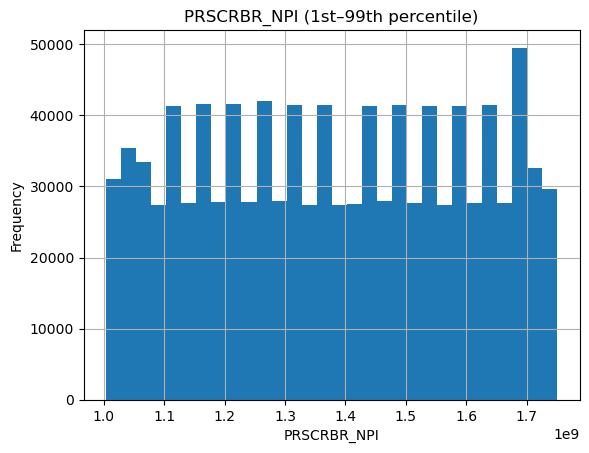

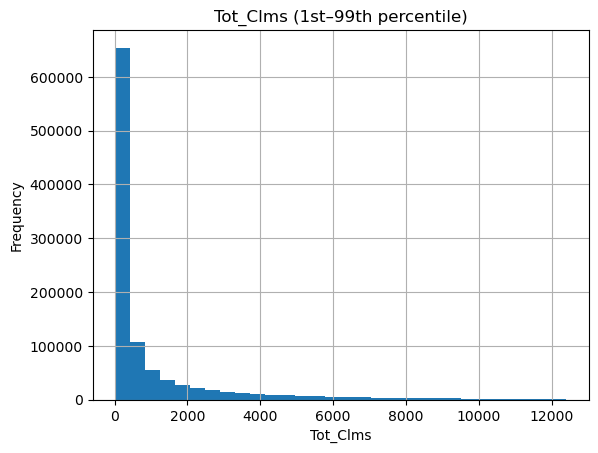

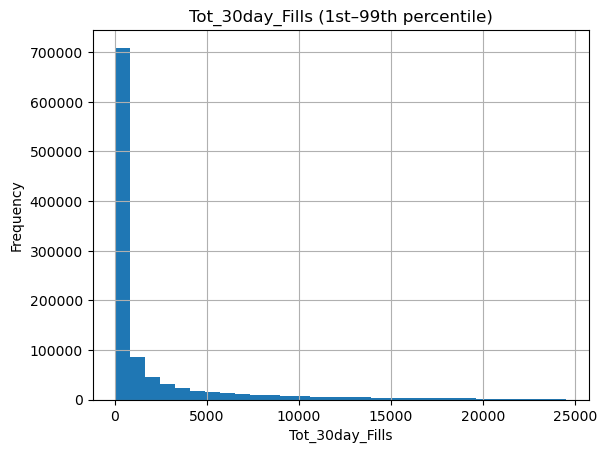

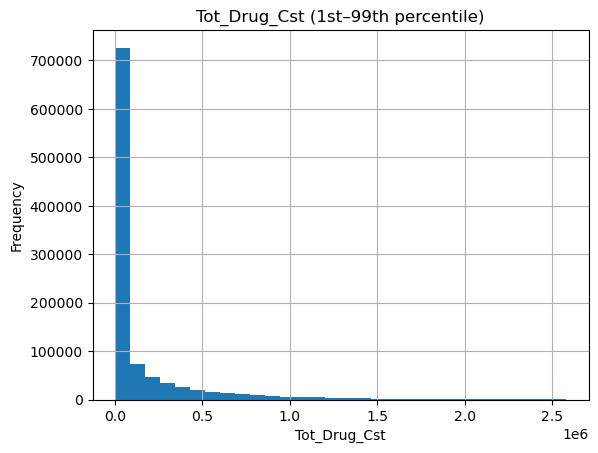

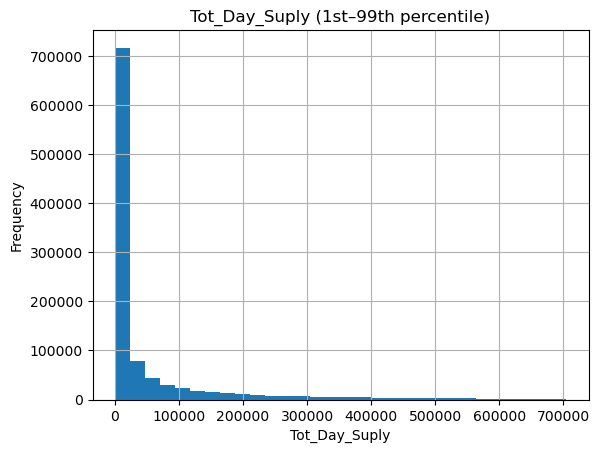

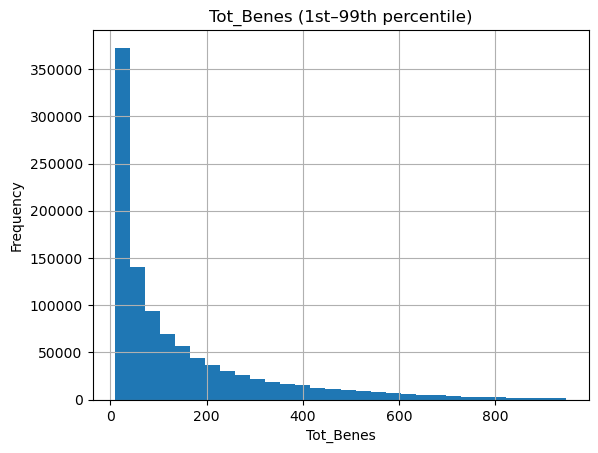

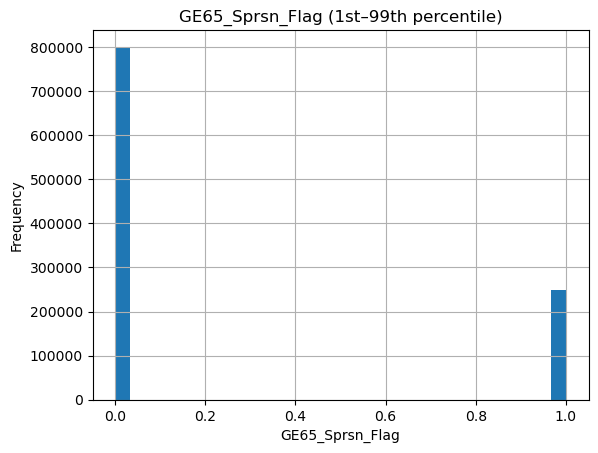

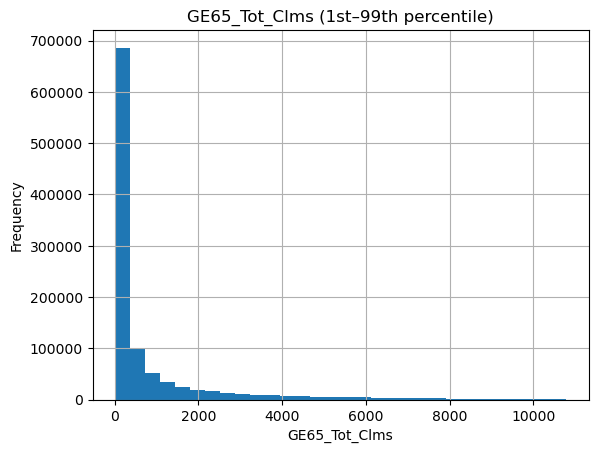

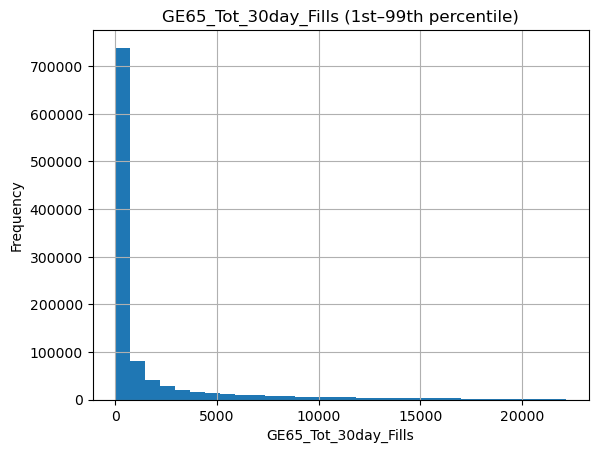

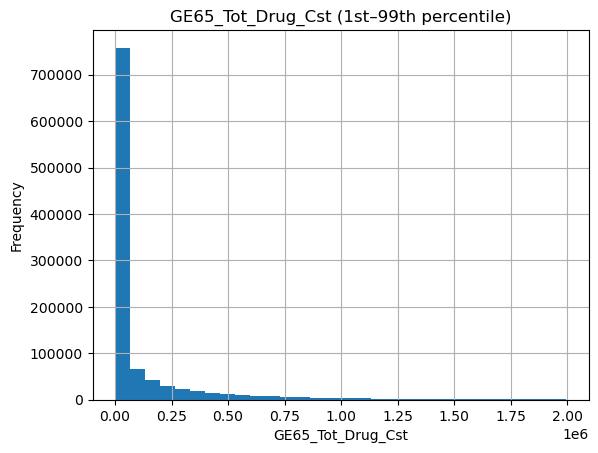

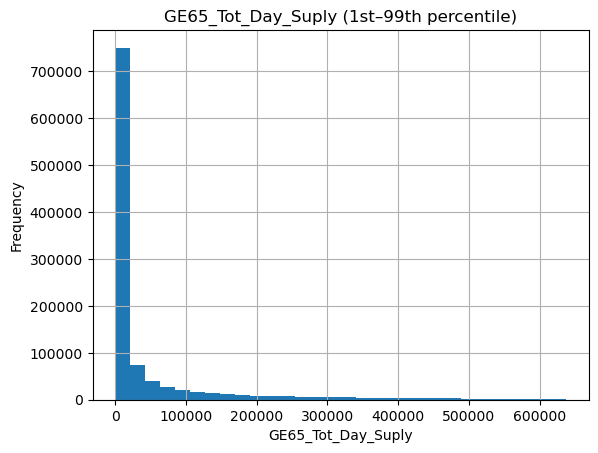

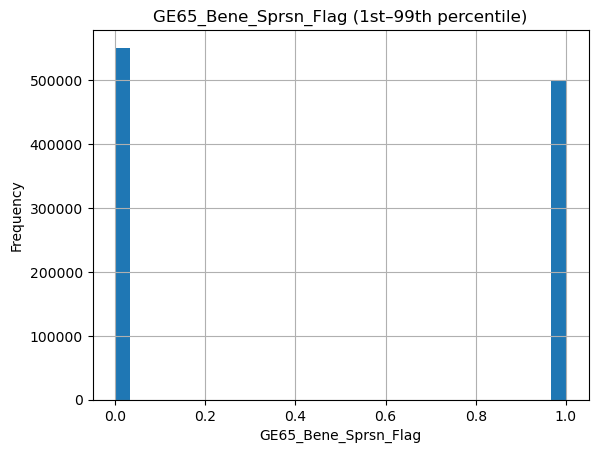

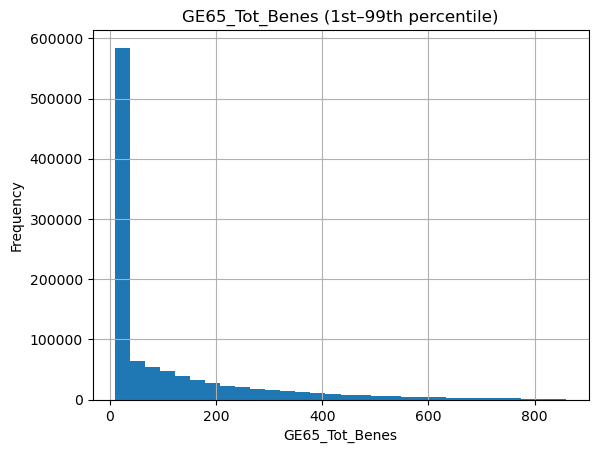

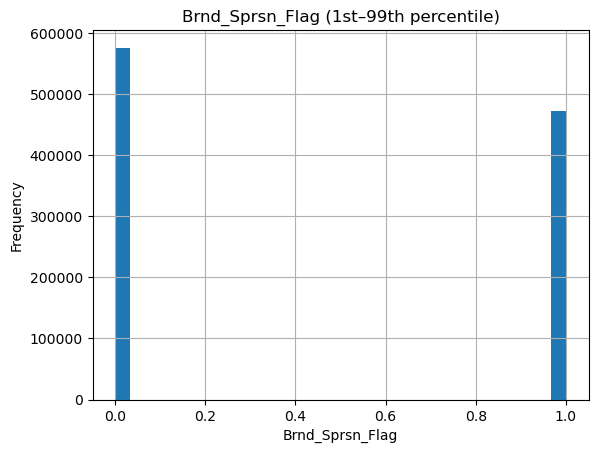

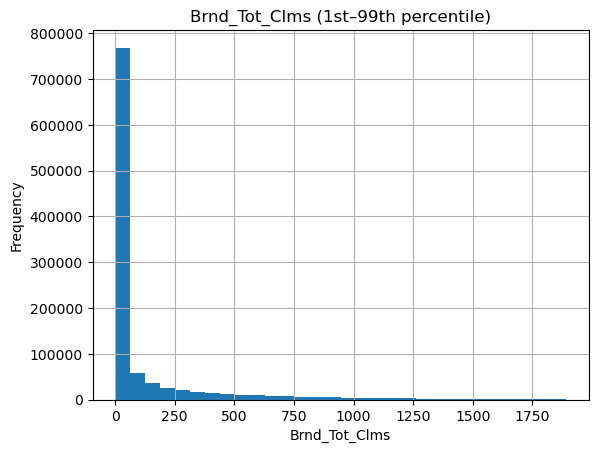

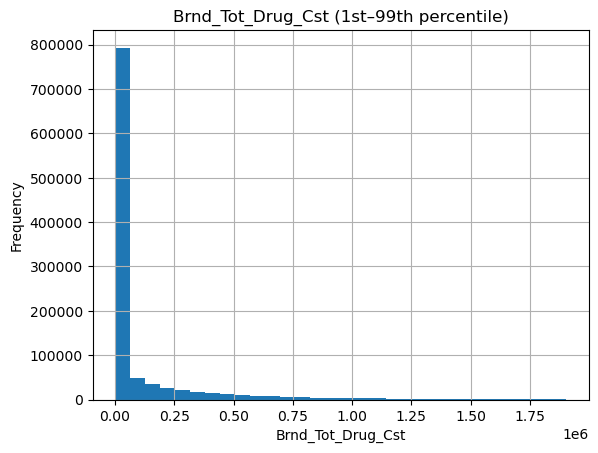

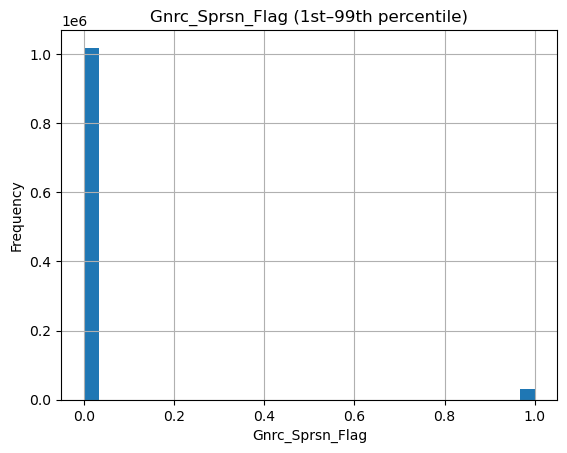

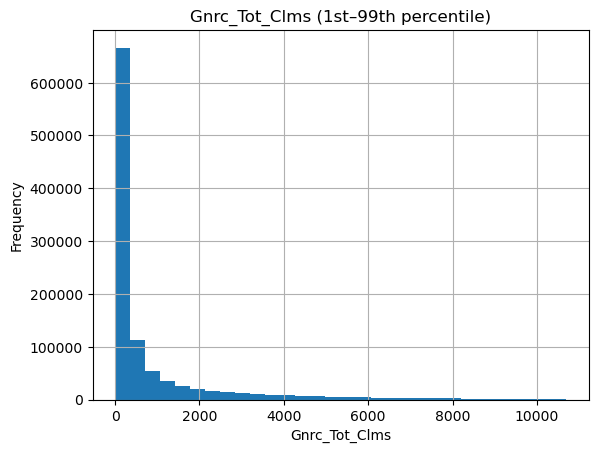

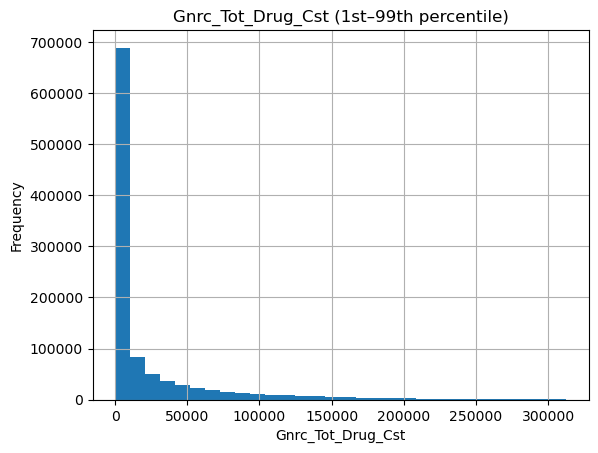

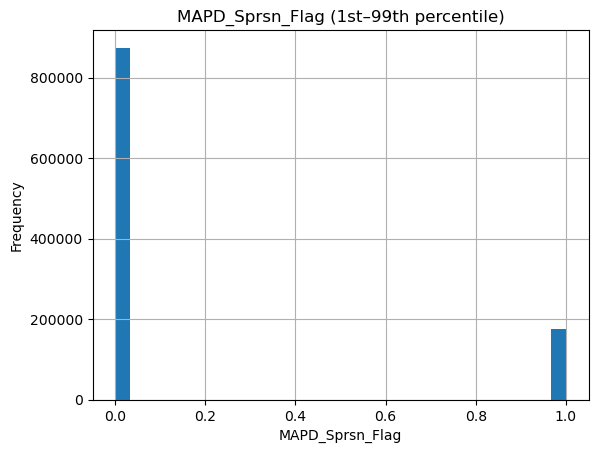

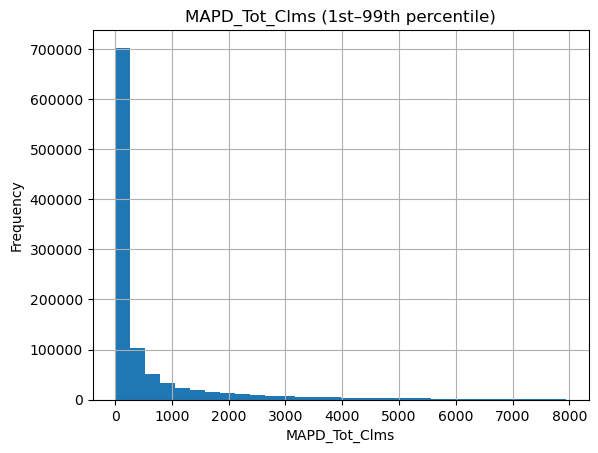

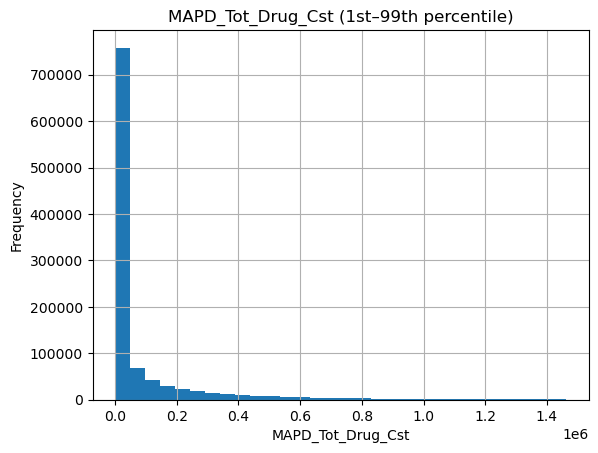

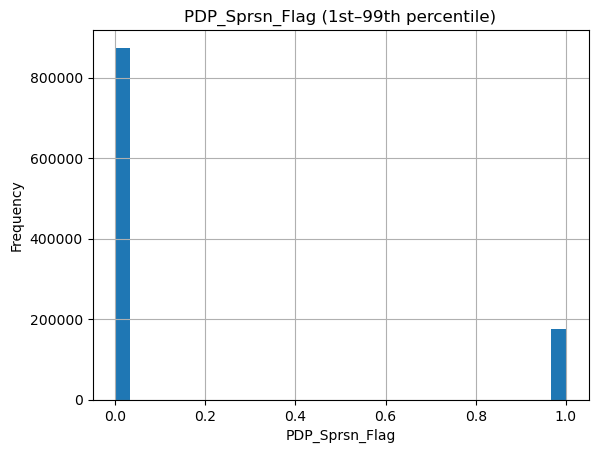

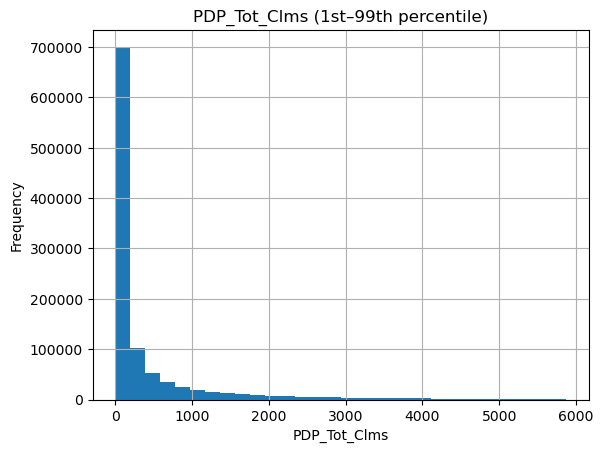

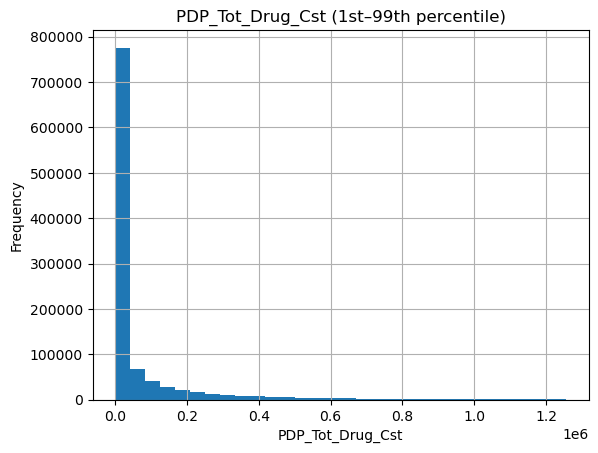

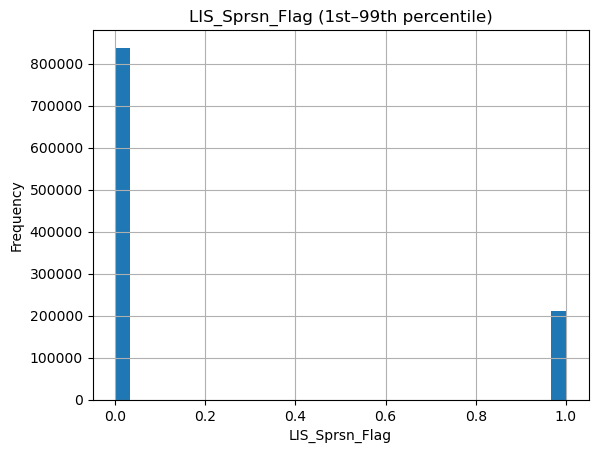

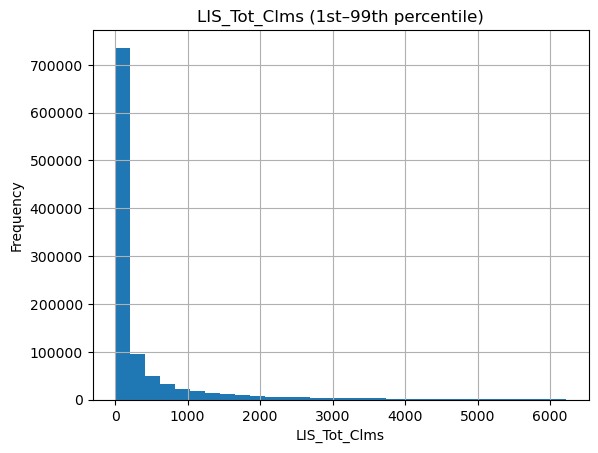

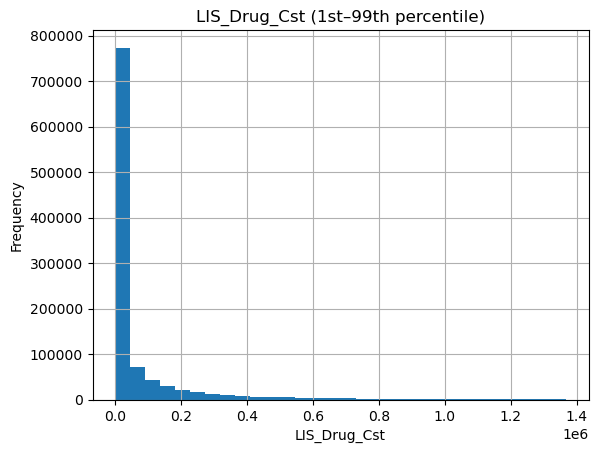

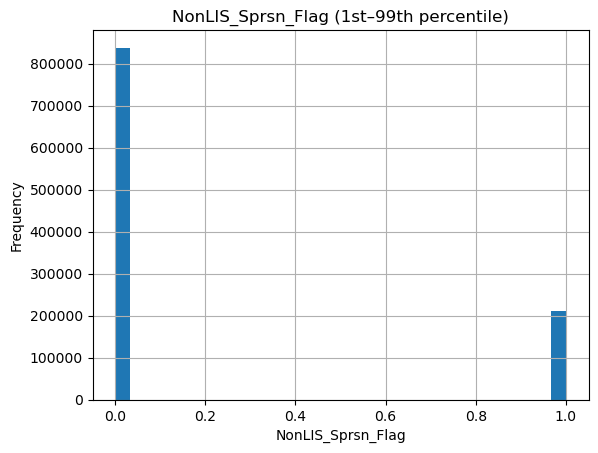

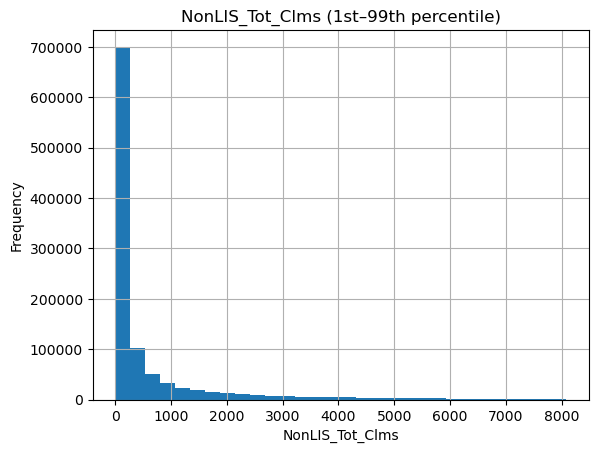

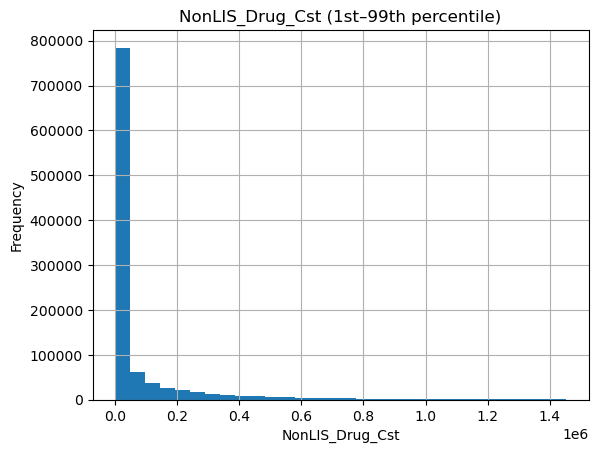

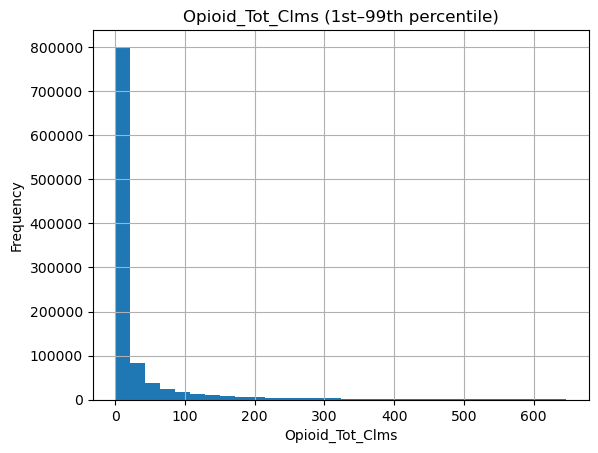

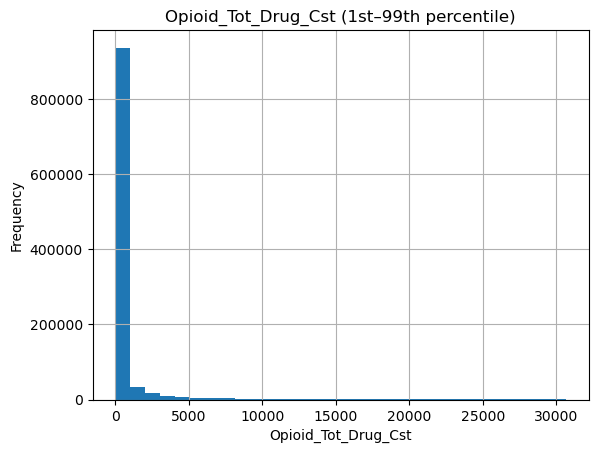

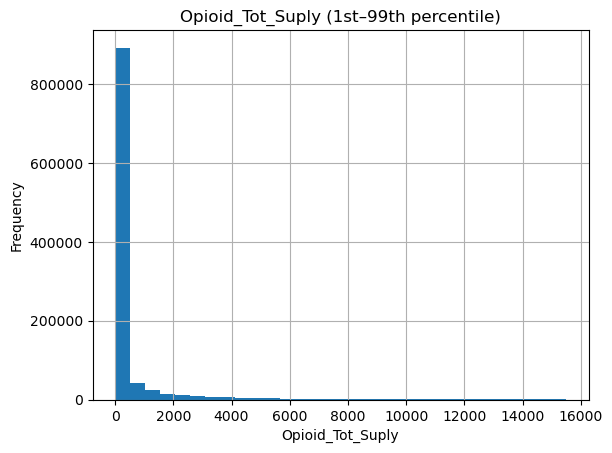

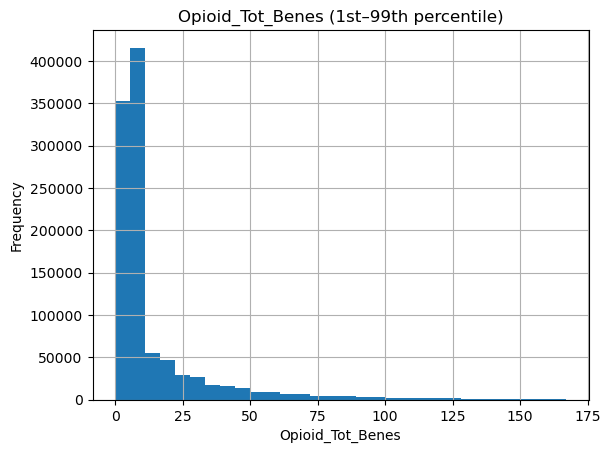

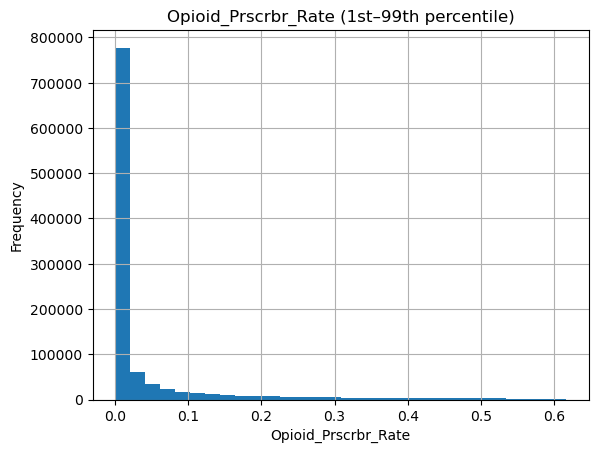

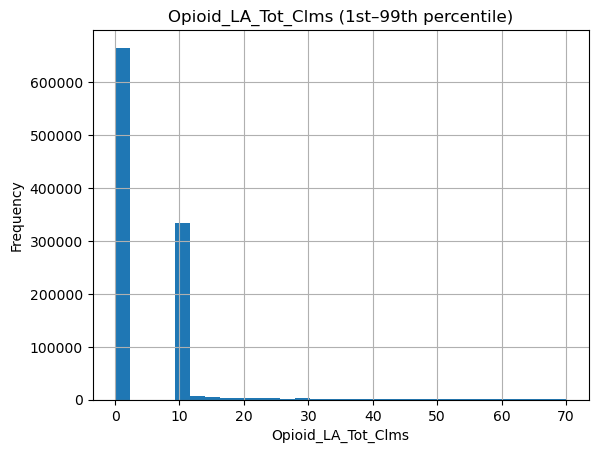

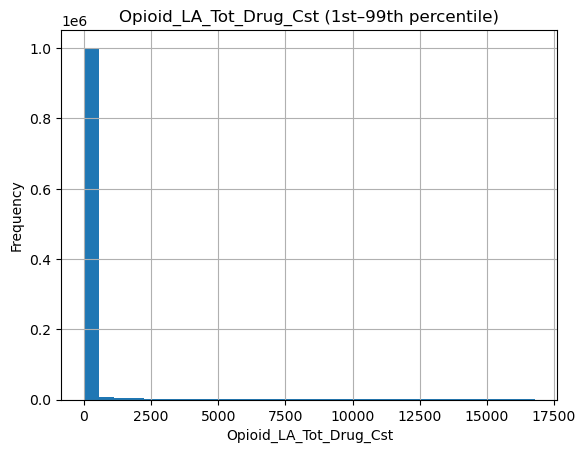

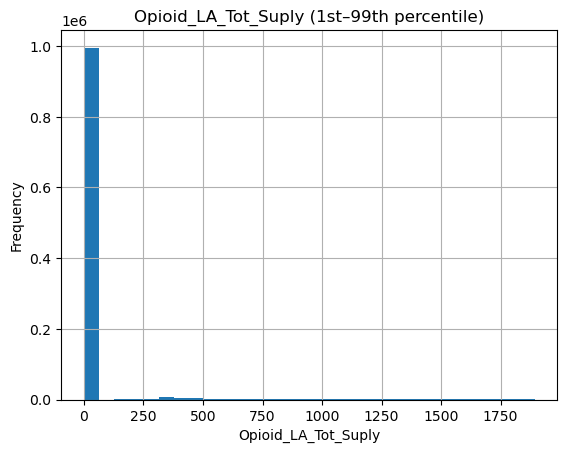

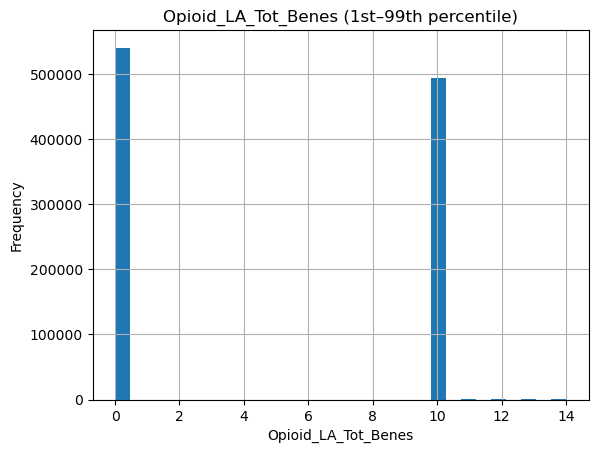

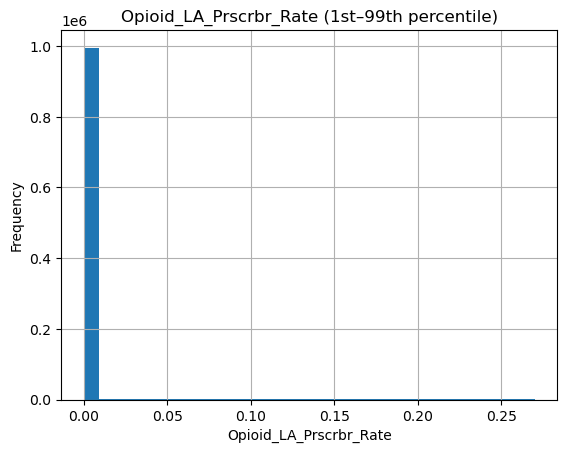

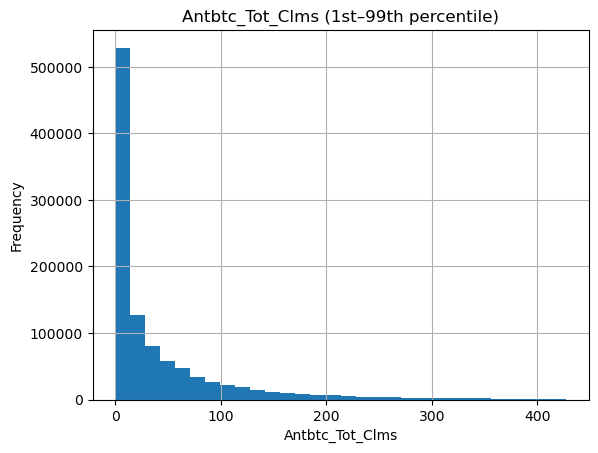

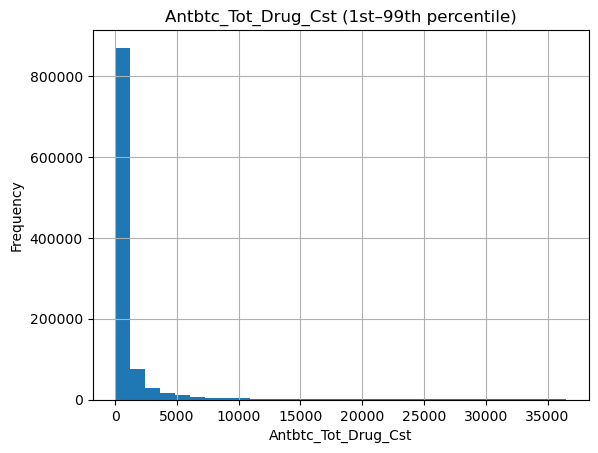

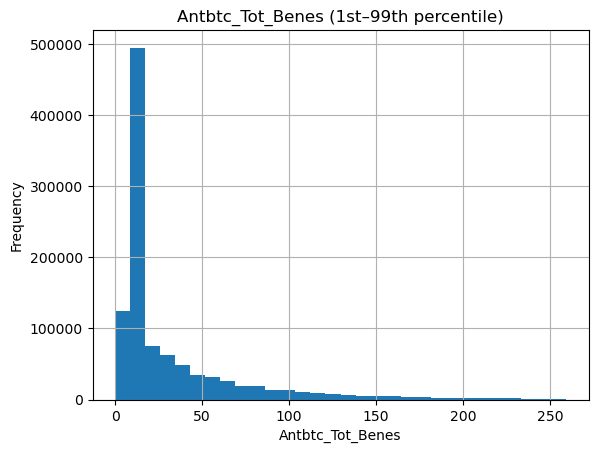

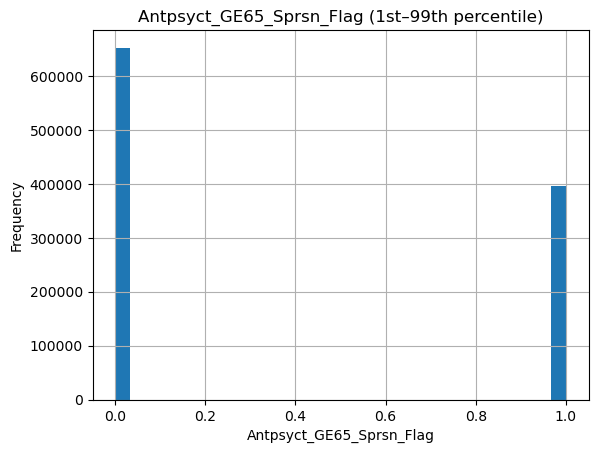

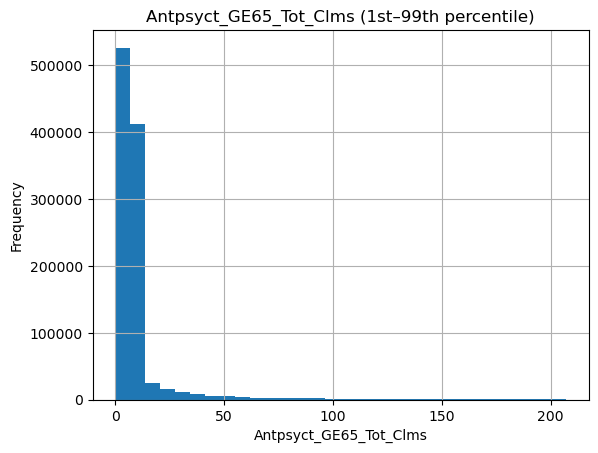

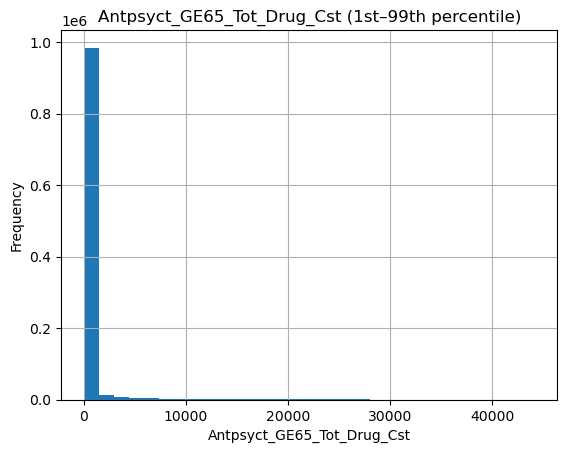

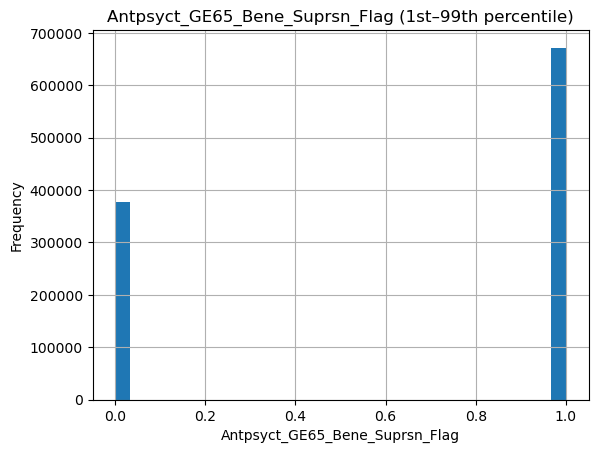

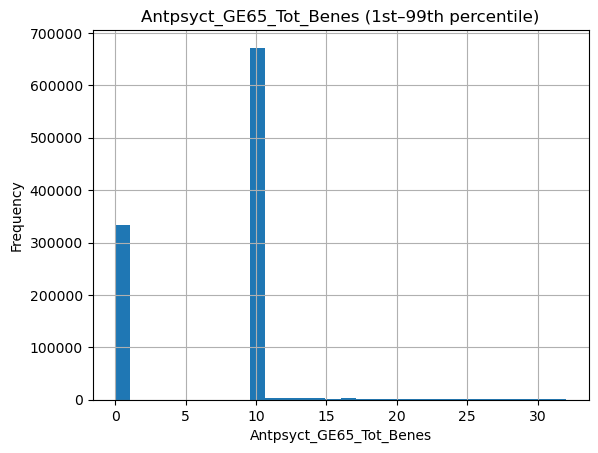

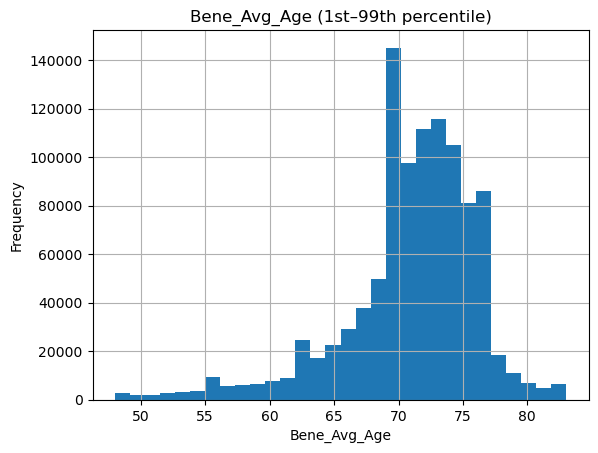

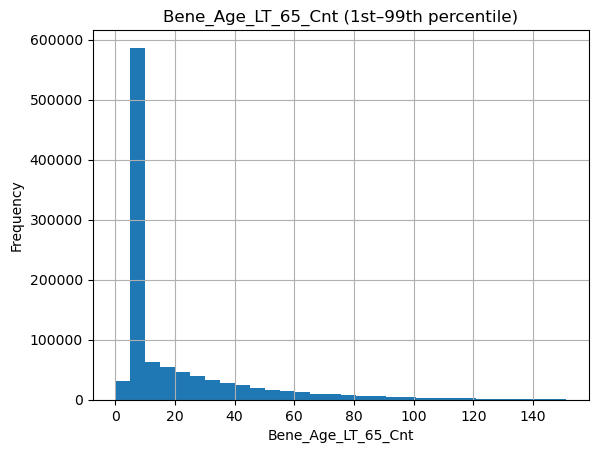

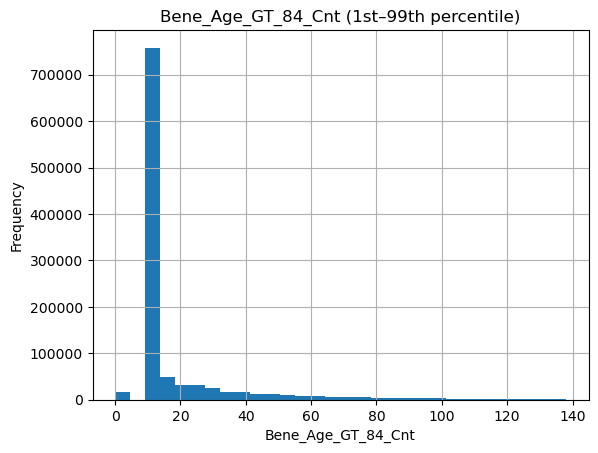

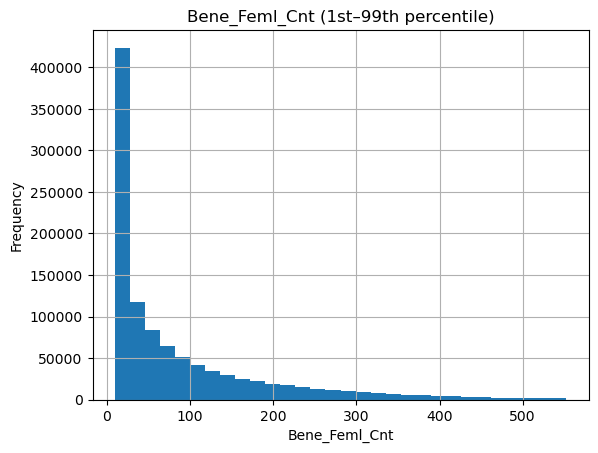

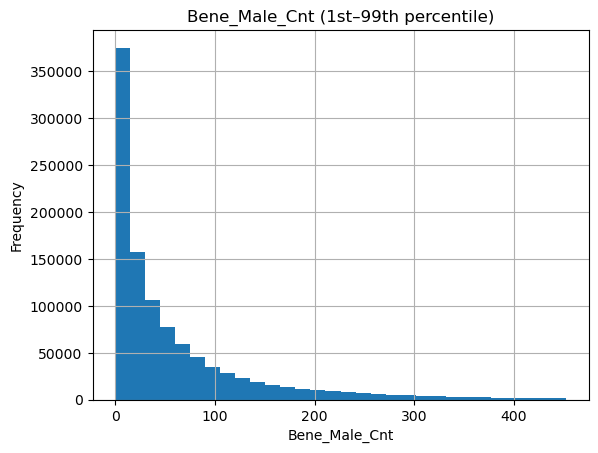

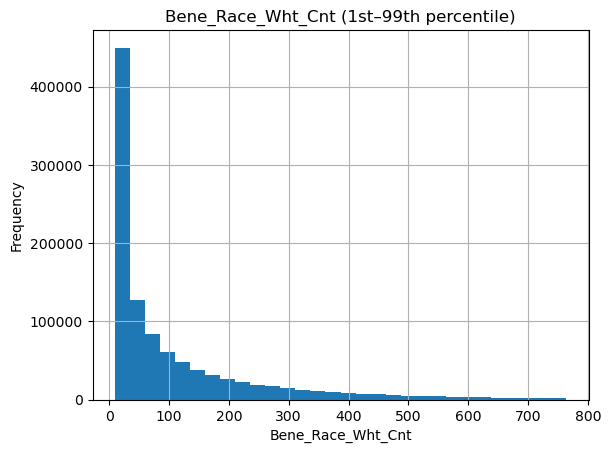

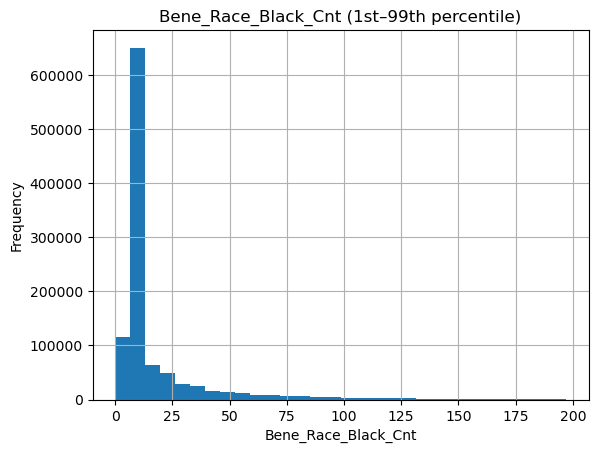

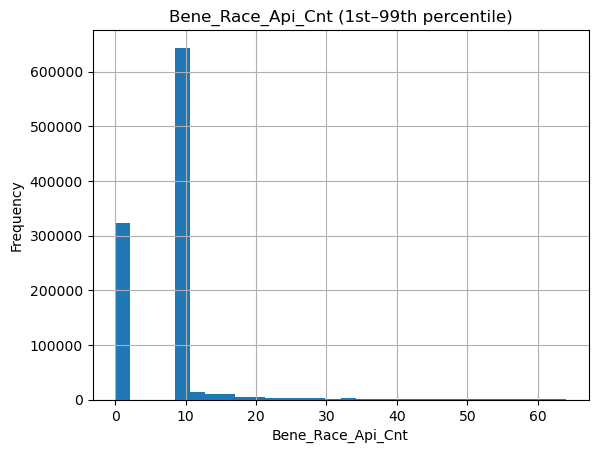

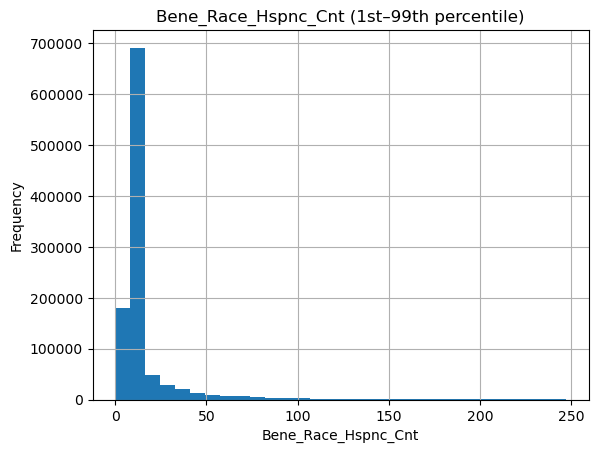

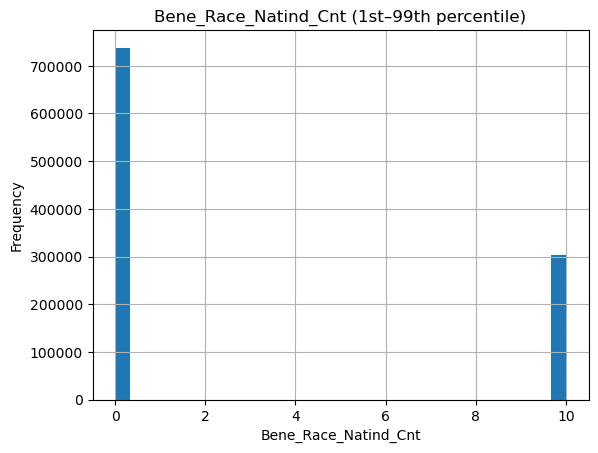

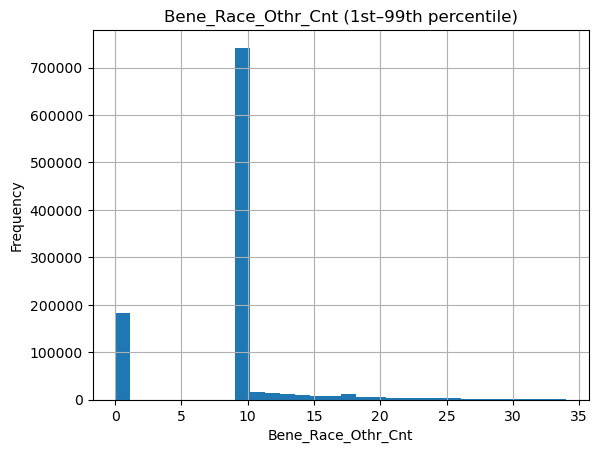

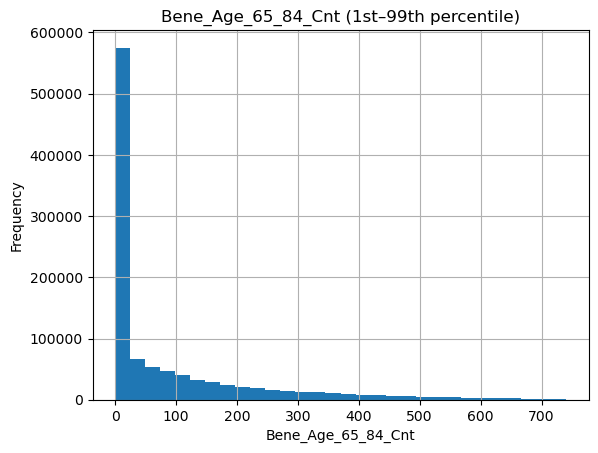

In [27]:
num_cols = df_op.select_dtypes(include='number').columns

for col in num_cols:
    lower = df_op[col].quantile(0.01)
    upper = df_op[col].quantile(0.99)
    
    df_op[col].hist(bins=30, range=(lower, upper))
    plt.title(f"{col} (1st–99th percentile)")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

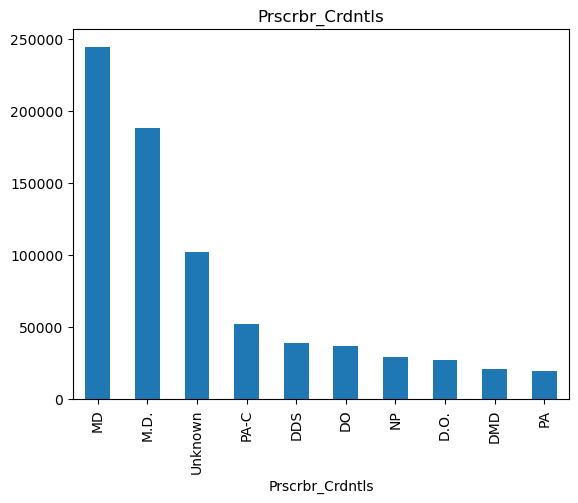

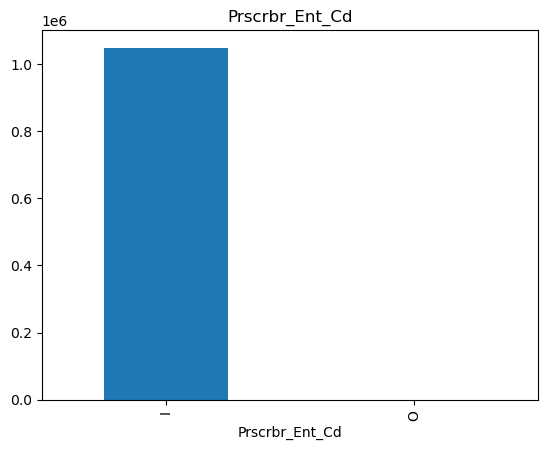

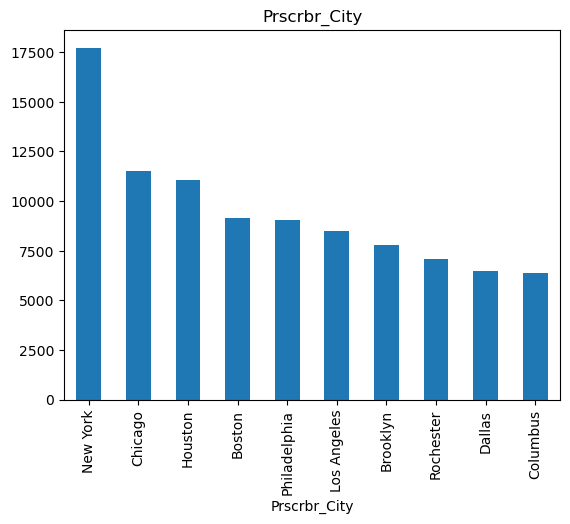

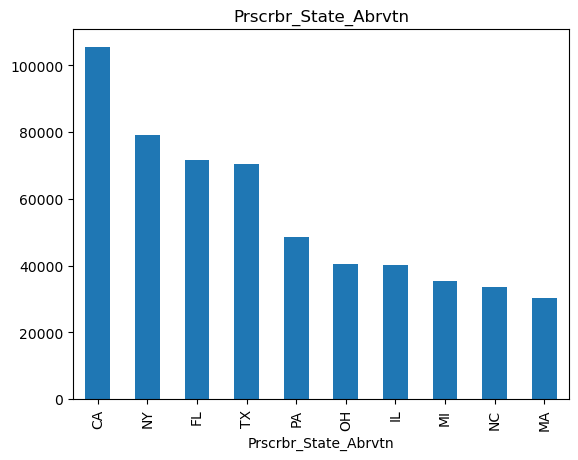

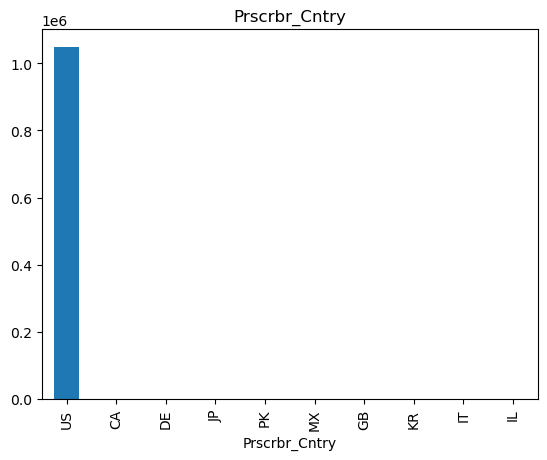

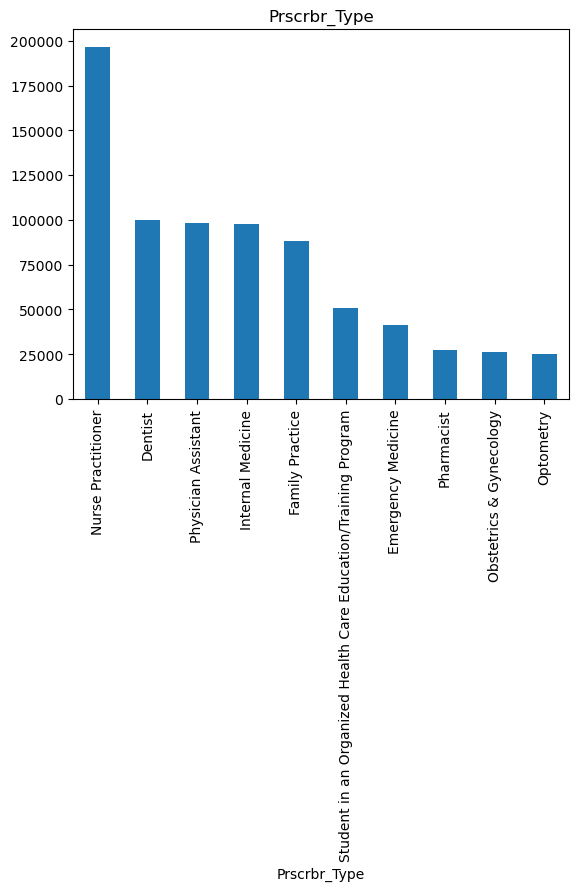

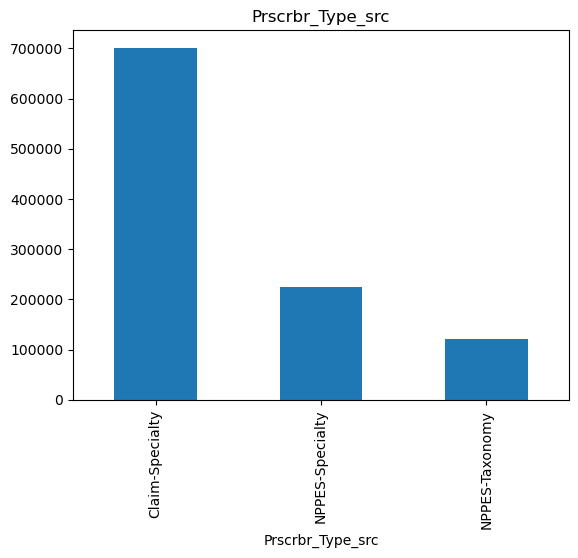

In [28]:
cat_cols = df_op.select_dtypes(include='string').columns

for col in cat_cols:
    df_op[col].value_counts().head(10).plot(kind='bar') #Change head count for more counts
    plt.title(col)
    plt.show()

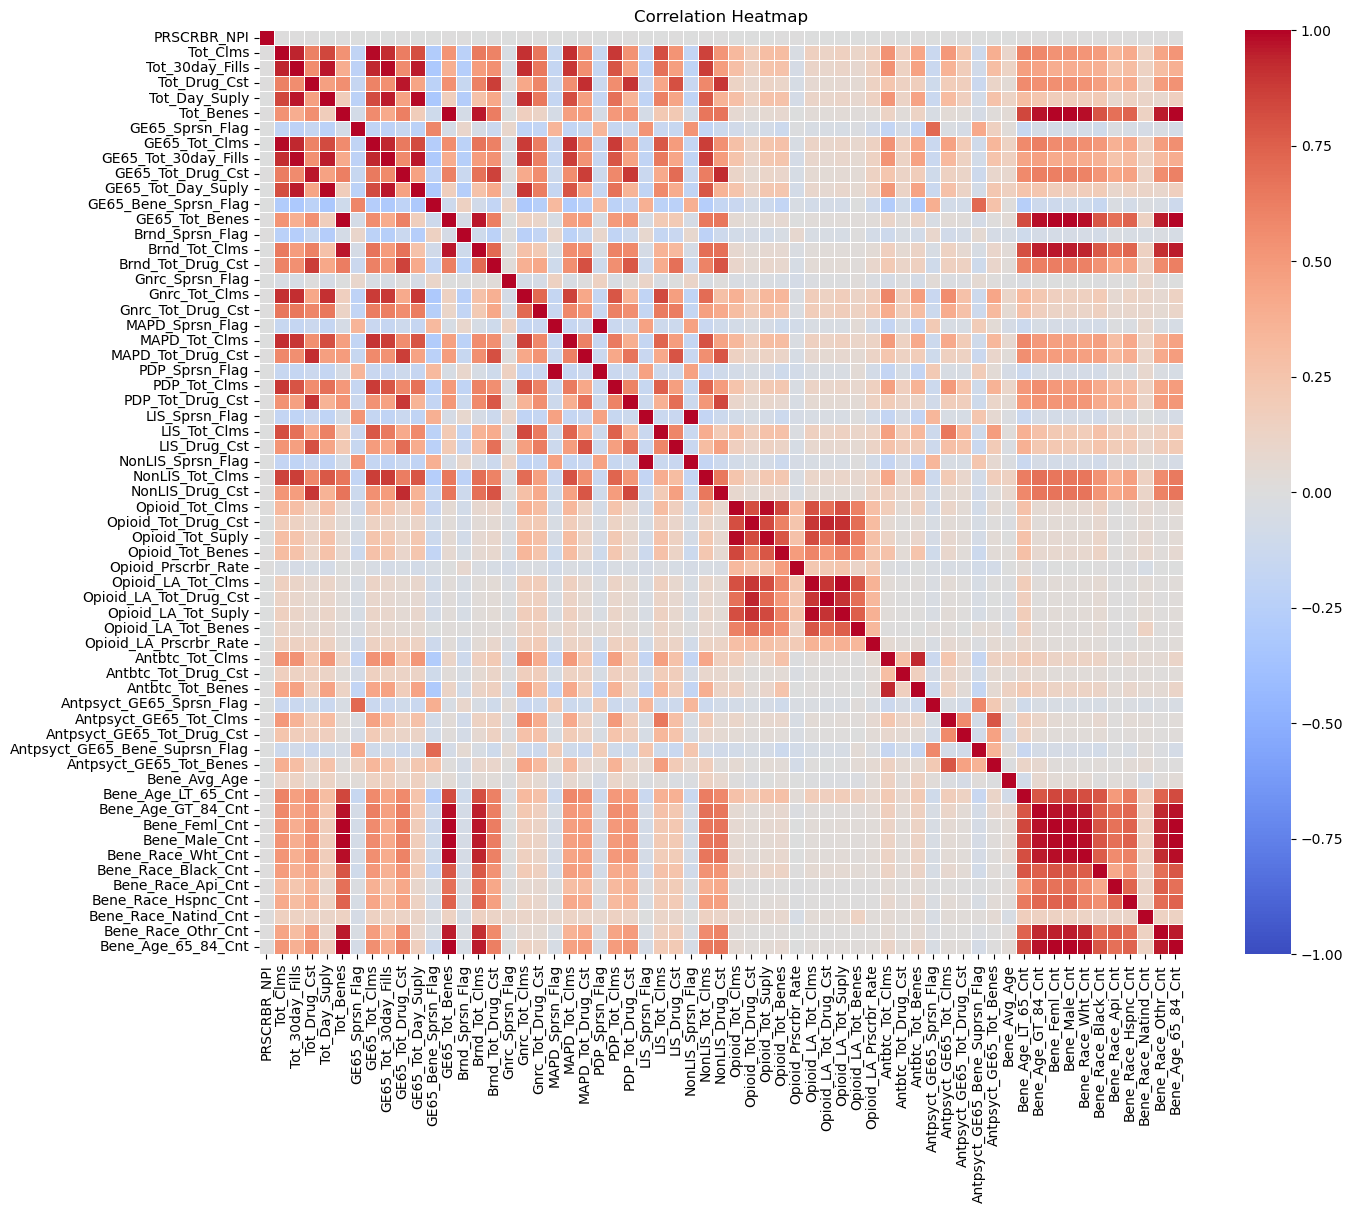

In [29]:
#I am specifying numeric columns with df_op_num.

df_op_num = df_op.select_dtypes(include = 'number')

matrix = df_op_num.corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    matrix,
    annot=False,       
    cmap='coolwarm',  
    vmin=-1,          
    vmax=1,
    center=0,         
    square=True,      
    linewidths=.5     
)

plt.title('Correlation Heatmap')
plt.show()

In [30]:
#Cost per patient features

df_op['Tot_Cst_Per_Bene'] = df_op['Tot_Drug_Cst'] / df_op['Tot_Benes']

df_op['GE65_Cst_Per_Bene'] = df_op['GE65_Tot_Drug_Cst'] / df_op['GE65_Tot_Benes']

df_op['Opioid_Cst_Per_Bene'] = df_op['Opioid_Tot_Drug_Cst'] / df_op['Opioid_Tot_Benes']

df_op['Opioid_LA_Cst_Per_Bene'] = df_op['Opioid_LA_Tot_Drug_Cst'] / df_op['Opioid_LA_Tot_Benes']

df_op['Antbtc_Cst_Per_Bene'] = df_op['Antbtc_Tot_Drug_Cst'] / df_op['Antbtc_Tot_Benes']

df_op['Antpsyct_GE65_Cst_Per_Bene'] = df_op['Antpsyct_GE65_Tot_Drug_Cst'] / df_op['Antpsyct_GE65_Tot_Benes']

## Data Modeling

In [92]:
# KPrototype is the model selected because the K-means modeling is not fit for data sets with categorical features.
# KPrototype is able to integrate both numerical and categorical data.

In [31]:
from kmodes.kprototypes import KPrototypes

In [32]:
# Creating my own copy of the operational data frame (ML).
df_op_ml = df_op.copy()

In [66]:
# Creating subset of the data: prescriber demographics + opioid data.

prdemo = df_op_ml[['Prscrbr_Crdntls', 'Prscrbr_Ent_Cd', 'Prscrbr_City', 'Prscrbr_State_Abrvtn', 'Prscrbr_RUCA', 'Prscrbr_Type', 'Prscrbr_Type_src', 'Tot_Clms', 'Tot_30day_Fills', 'Tot_Drug_Cst', 'Tot_Day_Suply', 'Tot_Benes', 'Opioid_Tot_Clms', 'Opioid_Tot_Drug_Cst', 'Opioid_Tot_Suply', 'Opioid_Tot_Benes', 'Opioid_Prscrbr_Rate']]
prdemo.head()

,Prscrbr_Crdntls,Prscrbr_Ent_Cd,Prscrbr_City,Prscrbr_State_Abrvtn,Prscrbr_RUCA,Prscrbr_Type,Prscrbr_Type_src,Tot_Clms,Tot_30day_Fills,Tot_Drug_Cst,Tot_Day_Suply,Tot_Benes,Opioid_Tot_Clms,Opioid_Tot_Drug_Cst,Opioid_Tot_Suply,Opioid_Tot_Benes,Opioid_Prscrbr_Rate
0,M.D.,I,Bethesda,MD,1.0,Hospitalist,Claim-Specialty,222,254.5,18399.98,5475,112.0,13.0,43.68,77.0,13.0,0.059
1,M.D.,I,Toledo,OH,1.0,Anesthesiology,Claim-Specialty,1865,1999.5,62623.40,55983,478.0,850.0,26878.15,23387.0,358.0,0.456
2,DDS,I,Dayton,NV,2.0,Dentist,NPPES-Specialty,118,119.0,456.67,806,59.0,10.0,0.00,0.0,10.0,0.000
3,M.D.,I,Cleveland,OH,1.0,Obstetrics & Gynecology,Claim-Specialty,162,340.0,19129.03,9260,64.0,0.0,0.00,0.0,0.0,0.000
4,MD,I,Aurora,CO,1.0,General Surgery,Claim-Specialty,41,47.1,1275.79,851,26.0,16.0,35.30,49.0,15.0,0.390


In [67]:
# Normalizing opioid data to overall total data.

prdemo['Opioid_Tot_Clms_norm'] = prdemo['Opioid_Tot_Clms']/prdemo['Tot_Clms']
prdemo['Opioid_Tot_Drug_Cst_norm'] = prdemo['Opioid_Tot_Drug_Cst']/prdemo['Tot_Drug_Cst']
prdemo['Opioid_Tot_Suply_norm'] = prdemo['Opioid_Tot_Suply']/prdemo['Tot_Day_Suply']
prdemo['Opioid_Tot_Benes_norm'] = prdemo['Opioid_Tot_Benes']/prdemo['Tot_Benes']

prdemo.head()

,Prscrbr_Crdntls,Prscrbr_Ent_Cd,Prscrbr_City,Prscrbr_State_Abrvtn,Prscrbr_RUCA,Prscrbr_Type,Prscrbr_Type_src,Tot_Clms,Tot_30day_Fills,Tot_Drug_Cst,...,Tot_Benes,Opioid_Tot_Clms,Opioid_Tot_Drug_Cst,Opioid_Tot_Suply,Opioid_Tot_Benes,Opioid_Prscrbr_Rate,Opioid_Tot_Clms_norm,Opioid_Tot_Drug_Cst_norm,Opioid_Tot_Suply_norm,Opioid_Tot_Benes_norm
0,M.D.,I,Bethesda,MD,1.0,Hospitalist,Claim-Specialty,222,254.5,18399.98,...,112.0,13.0,43.68,77.0,13.0,0.059,0.058559,0.002374,0.014064,0.116071
1,M.D.,I,Toledo,OH,1.0,Anesthesiology,Claim-Specialty,1865,1999.5,62623.40,...,478.0,850.0,26878.15,23387.0,358.0,0.456,0.455764,0.429203,0.417752,0.748954
2,DDS,I,Dayton,NV,2.0,Dentist,NPPES-Specialty,118,119.0,456.67,...,59.0,10.0,0.00,0.0,10.0,0.000,0.084746,0.000000,0.000000,0.169492
3,M.D.,I,Cleveland,OH,1.0,Obstetrics & Gynecology,Claim-Specialty,162,340.0,19129.03,...,64.0,0.0,0.00,0.0,0.0,0.000,0.000000,0.000000,0.000000,0.000000
4,MD,I,Aurora,CO,1.0,General Surgery,Claim-Specialty,41,47.1,1275.79,...,26.0,16.0,35.30,49.0,15.0,0.390,0.390244,0.027669,0.057579,0.576923


In [68]:
# Check for null values per column. I got an error when trying to run Kprototypes (ML).
print(prdemo.isnull().sum())

Prscrbr_Crdntls              0
Prscrbr_Ent_Cd               0
Prscrbr_City                 0
Prscrbr_State_Abrvtn         0
Prscrbr_RUCA                 0
Prscrbr_Type                 0
Prscrbr_Type_src             0
Tot_Clms                     0
Tot_30day_Fills              0
Tot_Drug_Cst                 0
Tot_Day_Suply                0
Tot_Benes                    0
Opioid_Tot_Clms              0
Opioid_Tot_Drug_Cst          0
Opioid_Tot_Suply             0
Opioid_Tot_Benes             0
Opioid_Prscrbr_Rate          0
Opioid_Tot_Clms_norm         0
Opioid_Tot_Drug_Cst_norm    22
Opioid_Tot_Suply_norm        0
Opioid_Tot_Benes_norm        0
dtype: int64
True


In [69]:
# Rows that have at least one NaN (ML).
nan_rows = prdemo[prdemo.isnull().any(axis=1)]
print(nan_rows)

        Prscrbr_Crdntls Prscrbr_Ent_Cd    Prscrbr_City Prscrbr_State_Abrvtn  \
67214   MSN, APRN, NP-C              I  Salt Lake City                   UT   
72543                MD              I         Memphis                   TN   
101667             M.D.              I       Allentown                   PA   
134819      ARNP, CWOCN              I       Lake City                   FL   
144199               MD              I         Atlanta                   GA   
158677          Unknown              I       Northport                   NY   
182055             M.D.              I       Salisbury                   NC   
223011             CRNP              I      Pittsburgh                   PA   
231066          Unknown              I       Las Vegas                   NV   
294236             M.D.              I        Woodside                   CA   
490722             O.D.              I      Trussville                   AL   
663771             M.D.              I        Richmo

In [70]:
# Replace NaN in prdemo with zero, because, upon inspection, the total drug cost and opioid total drug cost were both zero (ML).

prdemo['Opioid_Tot_Drug_Cst_norm'] = prdemo['Opioid_Tot_Drug_Cst_norm'].fillna(0)

In [71]:
# Checking data types in prdemo.

print(prdemo.dtypes)

Prscrbr_Crdntls                 str
Prscrbr_Ent_Cd                  str
Prscrbr_City                    str
Prscrbr_State_Abrvtn            str
Prscrbr_RUCA                 object
Prscrbr_Type                    str
Prscrbr_Type_src                str
Tot_Clms                      int64
Tot_30day_Fills             float64
Tot_Drug_Cst                float64
Tot_Day_Suply                 int64
Tot_Benes                   float64
Opioid_Tot_Clms             float64
Opioid_Tot_Drug_Cst         float64
Opioid_Tot_Suply            float64
Opioid_Tot_Benes            float64
Opioid_Prscrbr_Rate         float64
Opioid_Tot_Clms_norm        float64
Opioid_Tot_Drug_Cst_norm    float64
Opioid_Tot_Suply_norm       float64
Opioid_Tot_Benes_norm       float64
dtype: object


In [72]:
# Converting objects to strings.

prdemo['Prscrbr_RUCA'] = prdemo['Prscrbr_RUCA'].apply(str)
print(prdemo.dtypes)

Prscrbr_Crdntls                 str
Prscrbr_Ent_Cd                  str
Prscrbr_City                    str
Prscrbr_State_Abrvtn            str
Prscrbr_RUCA                    str
Prscrbr_Type                    str
Prscrbr_Type_src                str
Tot_Clms                      int64
Tot_30day_Fills             float64
Tot_Drug_Cst                float64
Tot_Day_Suply                 int64
Tot_Benes                   float64
Opioid_Tot_Clms             float64
Opioid_Tot_Drug_Cst         float64
Opioid_Tot_Suply            float64
Opioid_Tot_Benes            float64
Opioid_Prscrbr_Rate         float64
Opioid_Tot_Clms_norm        float64
Opioid_Tot_Drug_Cst_norm    float64
Opioid_Tot_Suply_norm       float64
Opioid_Tot_Benes_norm       float64
dtype: object


In [73]:
# Standardizing numeric data to zscore.

prdemo_num = prdemo[['Tot_Clms', 'Tot_30day_Fills', 'Tot_Drug_Cst', 'Tot_Day_Suply', 'Tot_Benes', 'Opioid_Prscrbr_Rate', 'Opioid_Tot_Clms_norm', 'Opioid_Tot_Drug_Cst_norm', 'Opioid_Tot_Suply_norm', 'Opioid_Tot_Benes_norm']]
prdemo_numz = pd.DataFrame(stats.zscore(prdemo_num, nan_policy = 'omit'), columns = prdemo_num.columns)
prdemo_numz.head()

,Tot_Clms,Tot_30day_Fills,Tot_Drug_Cst,Tot_Day_Suply,Tot_Benes,Opioid_Prscrbr_Rate,Opioid_Tot_Clms_norm,Opioid_Tot_Drug_Cst_norm,Opioid_Tot_Suply_norm,Opioid_Tot_Benes_norm
0,-0.308770,-0.362400,-0.278032,-0.378390,-0.051982,0.094393,-0.172873,-0.240897,-0.125587,-0.380841
1,0.224330,-0.026788,-0.210361,-0.026061,0.334353,3.349364,2.351422,4.173635,4.864621,1.533079
2,-0.342514,-0.388461,-0.305489,-0.410960,-0.107927,-0.389343,-0.006450,-0.265449,-0.299439,-0.219292
3,-0.328238,-0.345956,-0.276917,-0.351987,-0.102649,-0.389343,-0.545021,-0.265449,-0.299439,-0.731856
4,-0.367498,-0.402289,-0.304236,-0.410646,-0.142761,2.808235,1.935033,0.020722,0.412330,1.012835


In [74]:
# Checking against mean values in each column in prdemo_num.

print(prdemo_num.mean())

Tot_Clms                      1173.621493
Tot_30day_Fills               2138.781750
Tot_Drug_Cst                200095.989218
Tot_Day_Suply                59718.897638
Tot_Benes                      161.246067
Opioid_Prscrbr_Rate              0.047487
Opioid_Tot_Clms_norm             0.085761
Opioid_Tot_Drug_Cst_norm         0.025666
Opioid_Tot_Suply_norm            0.024223
Opioid_Tot_Benes_norm            0.242005
dtype: float64


In [75]:
# Comparing against standard deviation as well.

print(prdemo_num.describe())

           Tot_Clms  Tot_30day_Fills  Tot_Drug_Cst  Tot_Day_Suply  \
count  1.048575e+06     1.048575e+06  1.048575e+06   1.048575e+06   
mean   1.173621e+03     2.138782e+03  2.000960e+05   5.971890e+04   
std    3.081978e+03     5.199451e+03  6.535068e+05   1.433544e+05   
min    1.100000e+01     1.100000e+01  0.000000e+00   1.100000e+01   
25%    5.900000e+01     7.210000e+01  1.849625e+03   1.075000e+03   
50%    2.100000e+02     2.663000e+02  1.341479e+04   5.217000e+03   
75%    9.280000e+02     1.462600e+03  1.390551e+05   3.968400e+04   
max    6.662510e+05     6.673819e+05  1.602919e+08   7.288659e+06   

          Tot_Benes  Opioid_Prscrbr_Rate  Opioid_Tot_Clms_norm  \
count  1.048575e+06         1.048575e+06          1.048575e+06   
mean   1.612461e+02         4.748709e-02          8.576071e-02   
std    9.473633e+02         1.219674e-01          1.573531e-01   
min    1.000000e+01         0.000000e+00          0.000000e+00   
25%    2.500000e+01         0.000000e+00        

In [76]:
# Concatenate standardized columns (prdemo_numz) with categorical columns from prdemo.

#prdemo_f = pd.concat([prdemo[['Prscrbr_Crdntls', 'Prscrbr_Ent_Cd', 'Prscrbr_City', 'Prscrbr_State_Abrvtn', 'Prscrbr_RUCA', 'Prscrbr_Type', 'Prscrbr_Type_src']], prdemo_numz], axis = 1)
#prdemo_f.head()

In [77]:
# Concatenate standardized columns (prdemo_numz) with categorical columns from prdemo.

prdemo_cat = prdemo[['Prscrbr_Crdntls', 'Prscrbr_Ent_Cd', 'Prscrbr_City', 'Prscrbr_State_Abrvtn', 'Prscrbr_RUCA', 'Prscrbr_Type', 'Prscrbr_Type_src']]

prdemo_f = pd.concat([prdemo_cat, prdemo_numz], axis = 1)
prdemo_f.head()

,Prscrbr_Crdntls,Prscrbr_Ent_Cd,Prscrbr_City,Prscrbr_State_Abrvtn,Prscrbr_RUCA,Prscrbr_Type,Prscrbr_Type_src,Tot_Clms,Tot_30day_Fills,Tot_Drug_Cst,Tot_Day_Suply,Tot_Benes,Opioid_Prscrbr_Rate,Opioid_Tot_Clms_norm,Opioid_Tot_Drug_Cst_norm,Opioid_Tot_Suply_norm,Opioid_Tot_Benes_norm
0,M.D.,I,Bethesda,MD,1.0,Hospitalist,Claim-Specialty,-0.308770,-0.362400,-0.278032,-0.378390,-0.051982,0.094393,-0.172873,-0.240897,-0.125587,-0.380841
1,M.D.,I,Toledo,OH,1.0,Anesthesiology,Claim-Specialty,0.224330,-0.026788,-0.210361,-0.026061,0.334353,3.349364,2.351422,4.173635,4.864621,1.533079
2,DDS,I,Dayton,NV,2.0,Dentist,NPPES-Specialty,-0.342514,-0.388461,-0.305489,-0.410960,-0.107927,-0.389343,-0.006450,-0.265449,-0.299439,-0.219292
3,M.D.,I,Cleveland,OH,1.0,Obstetrics & Gynecology,Claim-Specialty,-0.328238,-0.345956,-0.276917,-0.351987,-0.102649,-0.389343,-0.545021,-0.265449,-0.299439,-0.731856
4,MD,I,Aurora,CO,1.0,General Surgery,Claim-Specialty,-0.367498,-0.402289,-0.304236,-0.410646,-0.142761,2.808235,1.935033,0.020722,0.412330,1.012835


In [78]:
# Need indices for categorical data.

prdemo_cat_cols = prdemo_f.select_dtypes(include = ['object', 'string', 'category']).columns.tolist()
print(prdemo_cat_cols)

prdemo_catidx = [prdemo_f.columns.get_loc(col) for col in prdemo_cat_cols]
print(prdemo_catidx)

['Prscrbr_Crdntls', 'Prscrbr_Ent_Cd', 'Prscrbr_City', 'Prscrbr_State_Abrvtn', 'Prscrbr_RUCA', 'Prscrbr_Type', 'Prscrbr_Type_src']
[0, 1, 2, 3, 4, 5, 6]


In [97]:
# Need indices for categorical data.

prdemo_cat_col_pos = [prdemo_f.columns.get_loc(col) for col in list(prdemo_f.select_dtypes(include = ['object', 'string', 'category']).columns)]
print('Categorical columns: {}'.format(list(prdemo_f.select_dtypes(include = ['object', 'string', 'category']).columns)))
print('Categorical columns position: {}'.format(prdemo_cat_col_pos))

Categorical columns: ['Prscrbr_Crdntls', 'Prscrbr_Ent_Cd', 'Prscrbr_City', 'Prscrbr_State_Abrvtn', 'Prscrbr_RUCA', 'Prscrbr_Type', 'Prscrbr_Type_src']
Categorical columns position: [0, 1, 2, 3, 4, 5, 6]


In [98]:
# Check for null values per column. I got an error when trying to run the kprototypes model (ML).
print(prdemo_f.isnull().sum())

Prscrbr_Crdntls             0
Prscrbr_Ent_Cd              0
Prscrbr_City                0
Prscrbr_State_Abrvtn        0
Prscrbr_RUCA                0
Prscrbr_Type                0
Prscrbr_Type_src            0
Tot_Clms                    0
Tot_30day_Fills             0
Tot_Drug_Cst                0
Tot_Day_Suply               0
Tot_Benes                   0
Opioid_Prscrbr_Rate         0
Opioid_Tot_Clms_norm        0
Opioid_Tot_Drug_Cst_norm    0
Opioid_Tot_Suply_norm       0
Opioid_Tot_Benes_norm       0
dtype: int64


In [107]:
# Create a sample set of prdemo (10% of data) for model optimization purposes.

prdemo_f_10 = prdemo_f.sample(frac = 0.1, random_state = 0)
prdemo_f_10.describe()

,Tot_Clms,Tot_30day_Fills,Tot_Drug_Cst,Tot_Day_Suply,Tot_Benes,Opioid_Prscrbr_Rate,Opioid_Tot_Clms_norm,Opioid_Tot_Drug_Cst_norm,Opioid_Tot_Suply_norm,Opioid_Tot_Benes_norm
count,104858.000000,104858.000000,104858.000000,104858.000000,104858.000000,104858.000000,104858.000000,104858.000000,104858.000000,104858.000000
mean,-0.000916,-0.000933,0.003107,-0.002080,0.005629,0.001419,0.004711,0.004309,0.004447,0.004095
std,1.155247,1.053111,1.247119,0.988864,1.848497,1.005867,1.007382,1.016454,1.015372,1.003260
min,-0.377232,-0.409232,-0.306188,-0.416506,-0.159650,-0.389343,-0.545021,-0.265449,-0.299439,-0.731856
25%,-0.361983,-0.397500,-0.303373,-0.409118,-0.143816,-0.389343,-0.545021,-0.265449,-0.299439,-0.731856
50%,-0.313637,-0.360362,-0.285825,-0.380560,-0.091038,-0.389343,-0.466540,-0.265449,-0.299439,-0.465362
75%,-0.080021,-0.130664,-0.094056,-0.141572,0.045129,-0.200768,0.051303,-0.240182,-0.211506,0.276187
max,215.795746,127.944948,244.973598,16.214491,519.177789,7.809575,5.810117,10.077174,12.062111,2.292274


In [108]:
# Remove opioid data from prdemo_f.

prdemo_fo_10 = prdemo_f_10[['Prscrbr_Crdntls', 'Prscrbr_Ent_Cd', 'Prscrbr_City', 'Prscrbr_State_Abrvtn', 'Prscrbr_RUCA', 'Prscrbr_Type', 'Prscrbr_Type_src', 'Tot_Clms', 'Tot_30day_Fills', 'Tot_Drug_Cst', 'Tot_Day_Suply', 'Tot_Benes']]
prdemo_fo.head()

,Prscrbr_Crdntls,Prscrbr_Ent_Cd,Prscrbr_City,Prscrbr_State_Abrvtn,Prscrbr_RUCA,Prscrbr_Type,Prscrbr_Type_src,Tot_Clms,Tot_30day_Fills,Tot_Drug_Cst,Tot_Day_Suply,Tot_Benes
0,M.D.,I,Bethesda,MD,1.0,Hospitalist,Claim-Specialty,-0.308770,-0.362400,-0.278032,-0.378390,-0.051982
1,M.D.,I,Toledo,OH,1.0,Anesthesiology,Claim-Specialty,0.224330,-0.026788,-0.210361,-0.026061,0.334353
2,DDS,I,Dayton,NV,2.0,Dentist,NPPES-Specialty,-0.342514,-0.388461,-0.305489,-0.410960,-0.107927
3,M.D.,I,Cleveland,OH,1.0,Obstetrics & Gynecology,Claim-Specialty,-0.328238,-0.345956,-0.276917,-0.351987,-0.102649
4,MD,I,Aurora,CO,1.0,General Surgery,Claim-Specialty,-0.367498,-0.402289,-0.304236,-0.410646,-0.142761


In [109]:
# Convert the data frame to a matrix.

prdemo_fmat = prdemo_fo_10.to_numpy()

In [106]:
# Use the elbow method to find the optimal number of clusters (k).

cost = []
for cluster in range(1, 10):
    try:
        kprototype_prdemo = KPrototypes(n_jobs = -1, n_clusters = cluster, init = 'Huang', random_state = 0)
        kprototype_prdemo.fit_predict(prdemo_fmat, categorical = prdemo_cat_col_pos)
        cost.append(kprototype_prdemo.cost_)
        print('Cluster initiation: {}'.format(cluster))
    except:
        break
        
# Converting the results into a dataframe and plotting them
prdemo_f_cost = pd.DataFrame({
    'Cluster': range(1, len(cost) + 1),
    'Cost': cost
})

# Data viz
plotnine.options.figure_size = (8, 4.8)
(
    ggplot(data = prdemo_f_cost)+
    geom_line(aes(x = 'Cluster',
                  y = 'Cost'))+
    geom_point(aes(x = 'Cluster',
                   y = 'Cost'))+
    geom_label(aes(x = 'Cluster',
                   y = 'Cost',
                   label = 'Cluster'),
               size = 10,
               nudge_y = 1000) +
    labs(title = 'Optimal number of cluster with Elbow Method')+
    xlab('Number of Clusters k')+
    ylab('Cost')+
    theme_minimal()
)

Cluster initiation: 1
Cluster initiation: 2
Cluster initiation: 3
Cluster initiation: 4
Cluster initiation: 5
Cluster initiation: 6
Cluster initiation: 7
Cluster initiation: 8
Cluster initiation: 9


ValueError: All arrays must be of the same length

In [84]:
#Run Kprototypes using k clusters as determined from the elbow plot above.

#prdemo_sample = prdemo_f.sample(frac = 0.02, random_state = 42)
#kproto_sample = KPrototypes(n_clusters = 5, init = 'Cao', random_state = 42)
#prdemo_cluster_sample = kproto_sample.fit_predict(prdemo_sample, categorical = prdemo_catidx)

kprototype_prdemo = KPrototypes(n_jobs = -1, n_clusters = 3, init = 'Huang', random_state = 0)
kprototype_prdemo.fit_predict(prdemo_fmat, categorical = prdemo_cat_col_pos)

In [ ]:
# Cluster centorid

kprototype_prdemo.cluster_centroids_

# Check the iteration of the clusters created

kprototype_prdemo.n_iter_

# Check the cost of the clusters created

kprototype_prdemo.cost_

In [ ]:
# Add the clusters to the prdemo_f_10 dataframe.
# Adjust map based on k clusters.
# If this doesn't work, then try into prdemo_fo_10 and then concatenate with the opioid data points.

prdemo_f_10['Cluster Labels'] = kprototype_prdemo.labels_
prdemo_f_10['Segment'] = prdemo_f_10['Cluster Labels'].map({0: 'Cluster 1', 1: 'Cluster 2', 2: 'Cluster 3', 3: 'Cluster 4', 4: 'Cluster 5'})

# Order the cluster
prdemo_f_10['Segment'] = prdemo_f_10['Segment'].astype('category')
prdemo_f_10['Segment'] = prdemo_f_10['Segment'].cat.reorder_categories(['Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4', 'Cluster 5'])

In [ ]:
# Cluster interpretation

prdemo_f_10.rename(columns = {'Cluster Labels':'Total'}, inplace = True)
prdemo_f_10.groupby('Segment').agg(
    {
        'Prscrbr_Crdntls':lambda x: x.value_counts().index[0],
        'Prscrbr_Ent_Cd': lambda x: x.value_counts().index[0],
        'Prscrbr_City': lambda x: x.value_counts().index[0],
        'Prscrbr_State_Abrvtn': lambda x: x.value_counts().index[0],
        'Prscrbr_RUCA': lambda x: x.value_counts().index[0],
        'Prscrbr_Type': lambda x: x.value_counts().index[0],
        'Prscrbr_Type_src': lambda x: x.value_counts().index[0],
        'Tot_Clms': 'mean',
        'Tot_30day_Fills': 'mean',
        'Tot_Drug_Cst': 'mean',
        'Tot_Day_Suply': 'mean',
        'Tot_Benes': 'mean',
        'Opioid_Tot_Clms': 'mean',
        'Opioid_Tot_Drug_Cst': 'mean',
        'Opioid_Tot_Suply': 'mean',
        'Opioid_Tot_Benes': 'mean',
        'Opioid_Prscrbr_Rate': 'mean'
    }
).reset_index()

In [87]:
#Looking at the event counts in each cluster.

prdemo_sample['cluster'] = prdemo_cluster_sample
prdemo_sample['cluster_label'] = prdemo_sample['cluster'].map({0: 'Cluster 1', 1: 'Cluster 2', 2: 'Cluster 3', 3: 'Cluster 4', 4: 'Cluster 5'})

print(prdemo_sample['cluster_label'].value_counts())

cluster_label
Cluster 2    12961
Cluster 3     4663
Cluster 1     2094
Cluster 4      901
Cluster 5      353
Name: count, dtype: int64


In [89]:
#Looking at the clusters against the numerical features.

prdemo_sample.groupby('cluster_label')[['Tot_Clms', 'Tot_30day_Fills', 'Tot_Drug_Cst', 'Tot_Day_Suply', 'Tot_Benes', 'Opioid_Prscrbr_Rate', 'Opioid_Tot_Clms_norm', 'Opioid_Tot_Drug_Cst_norm', 'Opioid_Tot_Suply_norm', 'Opioid_Tot_Benes_norm']].mean()

,Tot_Clms,Tot_30day_Fills,Tot_Drug_Cst,Tot_Day_Suply,Tot_Benes,Opioid_Prscrbr_Rate,Opioid_Tot_Clms_norm,Opioid_Tot_Drug_Cst_norm,Opioid_Tot_Suply_norm,Opioid_Tot_Benes_norm
cluster_label,,,,,,,,,,
Cluster 1,1.226177,1.507936,1.289859,1.594873,0.327257,-0.223101,-0.413695,-0.202715,-0.187455,-0.533452
Cluster 2,-0.197974,-0.232695,-0.140433,-0.241825,-0.035126,-0.281106,-0.359237,-0.229307,-0.242147,-0.528257
Cluster 3,-0.347157,-0.387685,-0.291785,-0.400331,-0.127890,0.176499,0.714805,-0.002015,0.012190,1.490954
Cluster 4,-0.174927,-0.279801,-0.251290,-0.301566,-0.032050,3.807439,2.707872,3.952833,3.953606,1.382945
Cluster 5,4.853636,5.184785,2.413639,5.163455,1.107572,-0.184672,-0.386120,-0.167788,-0.149115,-0.422175


In [91]:
#Looking at the clusters against the categorical features.

prdemo_sample.groupby('cluster_label')[['Prscrbr_Crdntls', 'Prscrbr_Ent_Cd', 'Prscrbr_City', 'Prscrbr_State_Abrvtn', 'Prscrbr_RUCA', 'Prscrbr_Type', 'Prscrbr_Type_src']].agg(lambda x: x.mode()[0])

,Prscrbr_Crdntls,Prscrbr_Ent_Cd,Prscrbr_City,Prscrbr_State_Abrvtn,Prscrbr_RUCA,Prscrbr_Type,Prscrbr_Type_src
cluster_label,,,,,,,
Cluster 1,MD,I,Houston,CA,1.0,Family Practice,Claim-Specialty
Cluster 2,MD,I,New York,CA,1.0,Nurse Practitioner,Claim-Specialty
Cluster 3,MD,I,New York,CA,1.0,Dentist,Claim-Specialty
Cluster 4,MD,I,Boston,CA,1.0,Physician Assistant,Claim-Specialty
Cluster 5,MD,I,San Antonio,TX,1.0,Family Practice,Claim-Specialty


KeyboardInterrupt: 